# MPP graphs

## HELP TOOLS

In [4]:
import os
# Omezíme paralelismus na 4 vlákna (ideální pro login node)
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

# Teprve TEĎ importuj zbytek
import pyarrow.parquet as pq
import numpy as np
import faiss

In [5]:
import urllib.parse
import re
import numpy as np
import pyarrow.parquet as pq
import faiss

def load_data_with_patient_parsing(parquet_path, embedding_col="vlad_raw"):
    # Načteme vše potřebné
    table = pq.read_table(parquet_path)
    print(f"Načteno {len(table)} řádků z {parquet_path}")
    table = pq.read_table(parquet_path, columns=[embedding_col, "__filename"])

    # Do těchto seznamů budeme ukládat jen "OK" data
    clean_embeddings = []
    clean_patient_ids = []
    clean_section_nums = []
    
    # Projdeme data řádek po řádku
    for i in range(len(table)):
        raw_filename = table.column("__filename")[i].as_py()
        
        # 1. Dekódování URL
        decoded_path = urllib.parse.unquote(raw_filename)
        filename = decoded_path.split('/')[-1].upper()
        
        # 2. FILTRY (Markery a Sub-řezy typu -1, -2)
        bad_markers = ["PSA", "CD34", "D240", "D2-40", "KI67", "ER", "PR", "HER2"]
        if any(m in filename for m in bad_markers):
            continue
        if re.search(r'(?:VEN|DORS|VENT)\d+-', filename):
            continue
            
        # 3. EXTRAKCE ČÍSLA ŘEZU A PACIENTA
        match = re.search(r'(?:VEN|DORS|VENT)[-]?(\d{1,2})', filename)
        if match:
            num = int(match.group(1))
            # Ignorujeme podezřelé řezy nad 12 (nebo je omezíme)
            if num > 13: 
                continue
                
            # Pacient ID ze složky (předposlední část cesty)
            parts = decoded_path.split('/')
            p_id = parts[-2] if len(parts) > 1 else "unknown"
            
            # Pokud vše prošlo, uložíme si embedding a info
            emb = table.column(embedding_col)[i].as_py()
            clean_embeddings.append(emb)
            clean_patient_ids.append(p_id)
            clean_section_nums.append(num)

    # Převod na numpy pole
    embeddings = np.array(clean_embeddings, dtype='float32')
    patient_ids = np.array(clean_patient_ids)
    section_nums = np.array(clean_section_nums)
    
    # Normalizace pro FAISS (pokud používáš IndexFlatIP)
    if len(embeddings) > 0:
        faiss.normalize_L2(embeddings)
    
    print(f"Původně načteno: {len(table)} řádků")
    print(f"Po filtraci zbylo: {len(embeddings)} čistých řezů")
    print(f"Unikátních pacientů: {len(np.unique(patient_ids))}")
    
    return patient_ids, section_nums, embeddings

In [6]:
import numpy as np
import faiss

def run_similarity_attack(embeddings, metadata_df, top_k=1):
    """
    Provede útok f(p). 
    embeddings: numpy array (N, dim)
    metadata_df: pandas DF s patient_id pro každý řádek v embeddings
    """
    dim = embeddings.shape[1]
    index = faiss.IndexFlatIP(dim) # Kosinová podobnost (pokud jsou vektory normované)
    index.add(embeddings)
    
    # Hledáme top_k + 1 (protože první výsledek bude vždy ta stejná sonda)
    distances, indices = index.search(embeddings, top_k + 1)
    
    # Vezmeme druhý nejbližší (index 1), abychom se neporovnávali sami se sebou
    top_1_indices = indices[:, 1]
    
    # Mapujeme indexy zpět na Patient ID
    patient_ids = metadata_df['patient_id'].values
    predictions = patient_ids[top_1_indices]
    
    results = metadata_df.copy()
    results['predicted_patient_id'] = predictions
    return results

In [7]:
def calculate_rs_pure_python(patient_ids, embeddings):
    n, dim = embeddings.shape
    index = faiss.IndexFlatIP(dim)
    index.add(embeddings)
    
    # Hledáme 2 nejbližší sousedy
    _, indices = index.search(embeddings, 2)
    
    # ID pacienta u nejbližšího souseda (vylučujeme sami sebe na indexu 0)
    neighbor_indices = indices[:, 1]
    predicted_ids = patient_ids[neighbor_indices]
    
    # Identifikace úspěšných útoků na úrovni sondy
    correct_mask = (patient_ids == predicted_ids)
    
    # Ruční "groupby" podle patient_id
    # Vytvoříme si set zranitelných pacientů
    vulnerable_patients = set()
    all_patients = set(patient_ids)
    
    for i in range(len(patient_ids)):
        if correct_mask[i]:
            vulnerable_patients.add(patient_ids[i])
            
    num_vulnerable = len(vulnerable_patients)
    total_patients = len(all_patients)
    rs = num_vulnerable / total_patients
    
    print(f"--- Výsledek Rs (Pure Python/Arrow) ---")
    print(f"Celkem unikátních pacientů: {total_patients}")
    print(f"Zranitelných pacientů: {num_vulnerable}")
    print(f"Finální R_s: {rs:.4f}")
    
    return rs

In [8]:
import os
import re
import urllib.parse
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import faiss
import gc
from pathlib import Path
from tqdm import tqdm

def analyze_20_seeds_with_patient_filter(base_path, encoders, tissues, methods):
    results_data = []

    for e_idx, e_key in enumerate(encoders):
        for t in tissues:
            # Cesta k hlavní složce
            main_path = Path(base_path) / f"privagams_enc{e_key}_mpp10_enhanced_slides_v5"
            print(f"\n--- Zpracovávám: {e_key} {t} ---")
            if not main_path.exists(): continue
            
            seed_folders = sorted([d for d in main_path.iterdir() if "run_seed_" in d.name])
            
            for sf in tqdm(seed_folders, desc=f"Seeds progress"):
                seed_val = sf.name.split("_")[-1]
                p_files = list(sf.glob("*.parquet"))
                if not p_files: continue

                # Pro každou metodu (Mean, VLAD, Fisher) musíme načíst a vyfiltrovat data
                for col in methods:
                    all_embs = []
                    all_pids = []
                    
                    # Procházíme jednotlivé slidy (parquety) v seedu
                    for pf in p_files:
                        try:
                            # Načteme potřebné sloupce (slide_id nahrazuje tvůj __filename)
                            table = pq.read_table(pf, columns=[col, "slide_id"])
                            
                            for i in range(len(table)):
                                raw_sid = table.column("slide_id")[i].as_py()
                                decoded_path = urllib.parse.unquote(raw_sid)
                                filename = decoded_path.split('/')[-1].upper()
                                
                                # --- TVOJE FILTRY ---
                                bad_markers = ["PSA", "CD34", "D240", "D2-40", "KI67", "ER", "PR", "HER2"]
                                if any(m in filename for m in bad_markers): continue
                                if re.search(r'(?:VEN|DORS|VENT)\d+-', filename): continue
                                    
                                match = re.search(r'(?:VEN|DORS|VENT)[-]?(\d{1,2})', filename)
                                if match:
                                    num = int(match.group(1))
                                    if num > 13: continue
                                        
                                    # Patient ID (předposlední část cesty)
                                    parts = decoded_path.split('/')
                                    p_id = parts[-2] if len(parts) > 1 else "unknown"
                                    
                                    emb = table.column(col)[i].as_py()
                                    all_embs.append(emb)
                                    all_pids.append(p_id)
                        except Exception:
                            continue # Přeskoč poškozené slidy

                    if not all_embs:
                        continue

                    # Převod na matici a výpočet Rs
                    embeddings = np.array(all_embs, dtype='float32')
                    patient_ids = np.array(all_pids)
                    faiss.normalize_L2(embeddings)
                    
                    rs_val = calculate_rs_pure_python(patient_ids, embeddings)
                    
                    results_data.append({
                        "enc": f"Encoder {e_idx}",
                        "method": col,
                        "rs_value": rs_val,
                        "type": t,
                        "seed": seed_val
                    })
                    
                    del embeddings, all_embs, all_pids
                    gc.collect()

    return pd.DataFrame(results_data)

def calculate_rs_pure_python(patient_ids, embeddings):
    n, dim = embeddings.shape
    if n < 2: return 0.0
    
    index = faiss.IndexFlatIP(dim)
    index.add(embeddings)
    
    # Hledáme 2 nejbližší (index 0 je on sám, index 1 je nejbližší soused)
    _, indices = index.search(embeddings, 2)
    
    neighbor_indices = indices[:, 1]
    predicted_ids = patient_ids[neighbor_indices]
    
    # Úspěšný "útok" = soused patří stejnému pacientovi
    correct_mask = (patient_ids == predicted_ids)
    
    # Rs = počet pacientů, u kterých se našel aspoň jeden správný match / počet všech pacientů
    vulnerable_patients = set(patient_ids[correct_mask])
    total_patients = len(set(patient_ids))
    
    return len(vulnerable_patients) / total_patients if total_patients > 0 else 0.0

# DATA LOADING FOR MPP10

In [ ]:
enc = ["0", "1", "2", "3", "4"]
mpp = ["10"]

emb_col = [
    "vlad_default",
    "vlad_default_super",
    "fisher_default",
    "fisher_default_super",
    "mean_default",
    "mean_default_super",
]

types = ["slides_v4"]
if os.path.exists("/home/jb88526/similarity/data/vysledky_20_seeds_patient_filter.csv"):
    df_vysledky = pd.read_csv("/home/jb88526/similarity/data/vysledky_20_seeds_patient_filter.csv")
else:
    df_vysledky = analyze_20_seeds_with_patient_filter("/data/fs201053/jb88526/", enc, types, emb_col)
    df_vysledky.to_csv("/home/jb88526/similarity/data/vysledky_20_seeds_patient_filter.csv", index=False)


--- Zpracovávám: 0 slides_v4 ---


Seeds progress: 100%|██████████| 20/20 [02:22<00:00,  7.12s/it]



--- Zpracovávám: 1 slides_v4 ---


Seeds progress: 100%|██████████| 20/20 [02:21<00:00,  7.07s/it]



--- Zpracovávám: 2 slides_v4 ---


Seeds progress: 100%|██████████| 20/20 [02:20<00:00,  7.05s/it]



--- Zpracovávám: 3 slides_v4 ---


Seeds progress: 100%|██████████| 20/20 [02:21<00:00,  7.06s/it]



--- Zpracovávám: 4 slides_v4 ---


Seeds progress: 100%|██████████| 20/20 [02:20<00:00,  7.04s/it]


# Slide Aggregator and Feature extractor comparison

/tmp/ipykernel_1883687/652351379.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right', fontsize=13)
/tmp/ipykernel_1883687/652351379.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right', fontsize=13)
/tmp/ipykernel_1883687/652351379.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right', fontsize=13)
/tmp/ipykernel_1883687/652351379.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right', fontsize=13)
/tmp

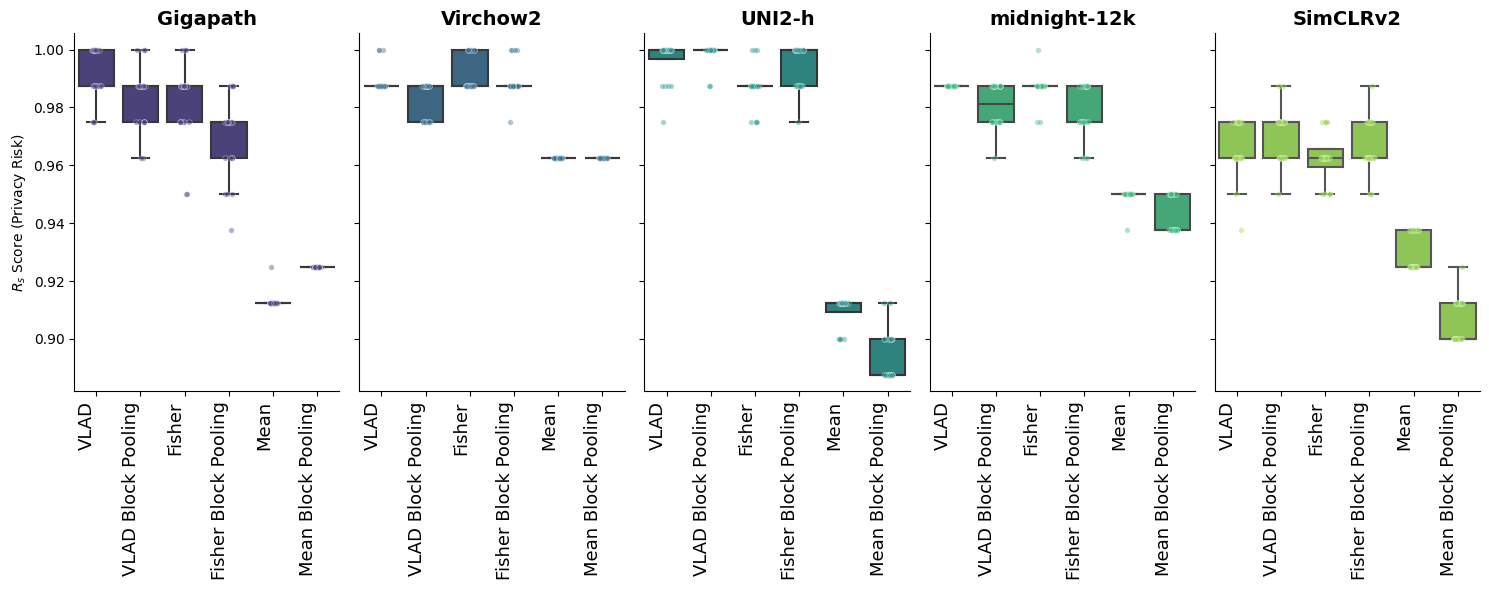

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Definice mapování
encoder_names = {
    "Encoder 0": "Gigapath",
    "Encoder 1": "Virchow2",
    "Encoder 2": "UNI2-h",
    "Encoder 3": "midnight-12k",
    "Encoder 4": "SimCLRv2"
}

method_names = {
    "vlad_default": "VLAD",
    "vlad_default_super": "VLAD Block Pooling",
    "fisher_default": "Fisher",
    "fisher_default_super": "Fisher Block Pooling",
    "mean_default": "Mean",
    "mean_default_super": "Mean Block Pooling"
}


# 2. Příprava dat
df_plot = df_vysledky.copy()
df_plot['enc'] = df_plot['enc'].map(encoder_names)
df_plot['method'] = df_plot['method'].map(method_names)

# !!! DŮLEŽITÉ: Musíme přejmenovat i seznam pro řazení (order) !!!
new_order = [method_names[m] for m in emb_col if m in method_names]

# 3. Vykreslení pomocí FacetGrid
g = sns.FacetGrid(
    df_plot, 
    col="enc", 
    hue="enc", 
    palette="viridis", 
    sharey=True, 
    height=6, 
    aspect=0.5 # Trochu užší, aby se jich vešlo víc vedle sebe
)

# Vykreslíme boxy a stripplot s NOVÝM pořadím
g.map(sns.boxplot, "method", "rs_value", order=new_order, showfliers=False, linewidth=1.5)
g.map(sns.stripplot, "method", "rs_value", order=new_order, jitter=True, alpha=0.4, size=4, linewidth=0.5, edgecolor="white")

# --- ÚPRAVY POPISKŮ A ESTETIKY ---
for ax in g.axes.flat:
    # ha='right' s rotací 45 nebo 60 vypadá obvykle lépe než 90, 
    # ale pokud máš dlouhé názvy, nech 90.
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right', fontsize=13)
    
    # Vyčištění nadpisů
    curr_title = ax.get_title()
    clean_title = curr_title.replace("enc = ", "")
    ax.set_title(clean_title, fontsize=14, fontweight='bold')

# Úprava popisků os a horní mezery pro nadpisy
g.set_axis_labels("", "$R_s$ Score (Privacy Risk)")
plt.subplots_adjust(top=0.85, wspace=0.1) # Mezery mezi grafy
plt.tight_layout()
plt.show()

# NONCONSECUTIVE SLIDES

In [55]:
import os
import re
import urllib.parse
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import faiss
import gc
from pathlib import Path
from tqdm import tqdm

def calculate_rs_by_distance(patient_ids, slice_nums, embeddings, max_dist=10):
    n, dim = embeddings.shape
    if n < 2: return {}
    
    index = faiss.IndexFlatIP(dim)
    index.add(embeddings)
    
    # Hledáme top sousedy
    k = min(50, n)
    distances, indices = index.search(embeddings, k)
    
    rs_results = {}
    total_patients = len(set(patient_ids))

    for d in range(1, max_dist + 1):
        vulnerable_patients = set()
        
        for i in range(n):
            current_pid = patient_ids[i]
            current_slice = slice_nums[i]
            target_slice = current_slice + d # Hledáme konkrétní vzdálenost
            
            # Útočník (slide i) se dívá do indexu a hledá:
            # "Je mezi mými nejbližšími sousedy slide mého pacienta s číslem (X + d)?"
            found_dist_match = False
            for neighbor_idx in indices[i, 1:]:
                # Pokud narazíme na jiného pacienta dřív, než najdeme náš vzdálený řez,
                # znamená to, že útok selhal (model je pro tento slide bezpečný)
                if patient_ids[neighbor_idx] != current_pid:
                    break 
                
                # Pokud je to náš pacient a má přesně tu vzdálenost, kterou testujeme
                if abs(slice_nums[neighbor_idx] - current_slice) == d:
                    found_dist_match = True
                    break
            
            if found_dist_match:
                vulnerable_patients.add(current_pid)
        
        rs_results[d] = len(vulnerable_patients) / total_patients if total_patients > 0 else 0.0
        
    return rs_results

def run_full_distance_analysis(base_path, encoders, methods, max_dist=10):
    all_results = []

    for e_idx, e_key in enumerate(encoders):
        # Cesta odpovídá tvé v5 struktuře
        main_path = Path(base_path) / f"privagams_enc{e_key}_mpp10_enhanced_slides_v5"
        
        if not main_path.exists():
            print(f"Složka nenalezena: {main_path}")
            continue
            
        print(f"\n>>> Zpracovávám Encoder: {e_key}")
        seed_folders = sorted([d for d in main_path.iterdir() if "run_seed_" in d.name])
        
        for sf in tqdm(seed_folders, desc="Seeds"):
            seed_val = sf.name.split("_")[-1]
            p_files = list(sf.glob("*.parquet"))
            if not p_files: continue

            for col in methods:
                all_embs, all_pids, all_slices = [], [], []
                
                for pf in p_files:
                    try:
                        table = pq.read_table(pf, columns=[col, "slide_id"])
                        for i in range(len(table)):
                            raw_sid = table.column("slide_id")[i].as_py()
                            decoded_path = urllib.parse.unquote(raw_sid)
                            filename = decoded_path.split('/')[-1].upper()
                            
                            # --- TVOJE FILTRY ---
                            bad_markers = ["PSA", "CD34", "D240", "D2-40", "KI67", "ER", "PR", "HER2"]
                            if any(m in filename for m in bad_markers): continue
                            if re.search(r'(?:VEN|DORS|VENT)\d+-', filename): continue
                                
                            match = re.search(r'(?:VEN|DORS|VENT)[-]?(\d{1,2})', filename)
                            if match:
                                s_num = int(match.group(1))
                                if s_num > 13: continue
                                    
                                p_id = decoded_path.split('/')[-2]
                                all_embs.append(table.column(col)[i].as_py())
                                all_pids.append(p_id)
                                all_slices.append(s_num)
                    except: continue

                if not all_embs: continue

                # Příprava dat pro FAISS
                embeddings = np.array(all_embs, dtype='float32')
                patient_ids = np.array(all_pids)
                slice_nums = np.array(all_slices)
                faiss.normalize_L2(embeddings)
                
                # Výpočet Rs pro všechny vzdálenosti najednou
                rs_dist_map = calculate_rs_by_distance(patient_ids, slice_nums, embeddings, max_dist)
                
                for d, val in rs_dist_map.items():
                    all_results.append({
                        "encoder": e_key,
                        "method": col,
                        "seed": seed_val,
                        "distance": d,
                        "rs_value": val
                    })
                
                del embeddings; gc.collect()

    return pd.DataFrame(all_results)

# --- NASTAVENÍ A SPUŠTĚNÍ ---
# Uprav base_path podle svého prostředí
BASE_PATH = "/data/fs201053/jb88526/" 
#ENCODERS = ["0"] # Gigapath, Virchow2, UNI2-h, midnight, SimCLR
#METHODS = ["vlad_default"]

ENCODERS = ["0", "1", "2", "3", "4"] # Gigapath, Virchow2, UNI2-h, midnight, SimCLR
METHODS = [
    "vlad_default",
    "vlad_default_super",
    "fisher_default",
    "fisher_default_super",
    "mean_default",
    "mean_default_super",
]

if os.path.exists("/home/jb88526/similarity/data/rs_distance_analysis.csv"):
    df_final_dist = pd.read_csv("/home/jb88526/similarity/data/rs_distance_analysis.csv")
else:
    df_final_dist = run_full_distance_analysis(BASE_PATH, ENCODERS, METHODS)
    # Uložení výsledků
    df_final_dist.to_csv("/home/jb88526/similarity/data/rs_distance_analysis.csv", index=False)

print("\nHotovo! Výsledky uloženy do rs_distance_analysis.csv")
print(df_final_dist.head(20))


Hotovo! Výsledky uloženy do rs_distance_analysis.csv
    encoder              method  seed  distance  rs_value
0         0        vlad_default    42         1    0.9875
1         0        vlad_default    42         2    0.5875
2         0        vlad_default    42         3    0.2500
3         0        vlad_default    42         4    0.0750
4         0        vlad_default    42         5    0.0250
5         0        vlad_default    42         6    0.0125
6         0        vlad_default    42         7    0.0125
7         0        vlad_default    42         8    0.0000
8         0        vlad_default    42         9    0.0000
9         0        vlad_default    42        10    0.0000
10        0  vlad_default_super    42         1    0.9750
11        0  vlad_default_super    42         2    0.5625
12        0  vlad_default_super    42         3    0.2625
13        0  vlad_default_super    42         4    0.1125
14        0  vlad_default_super    42         5    0.0250
15        0  vlad_

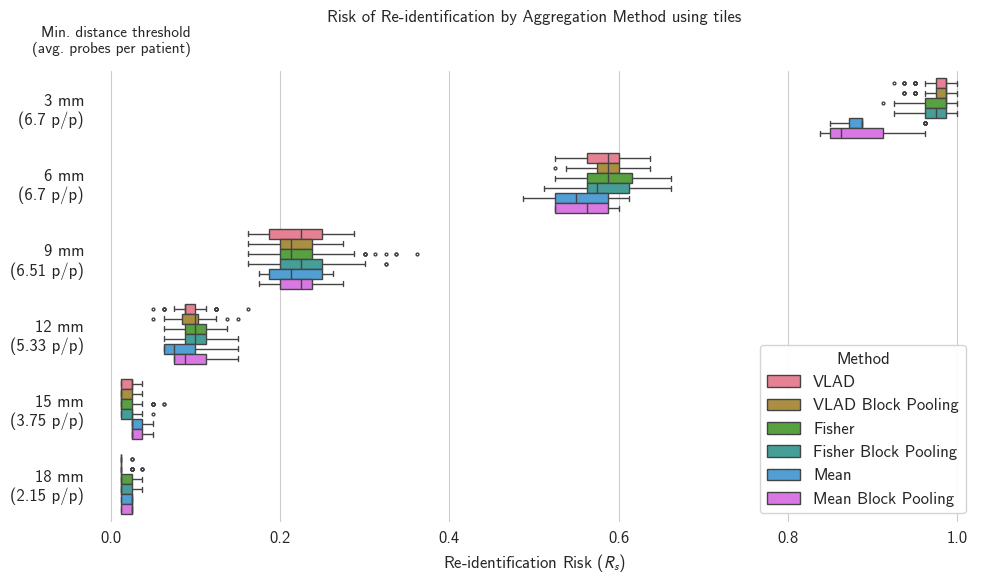

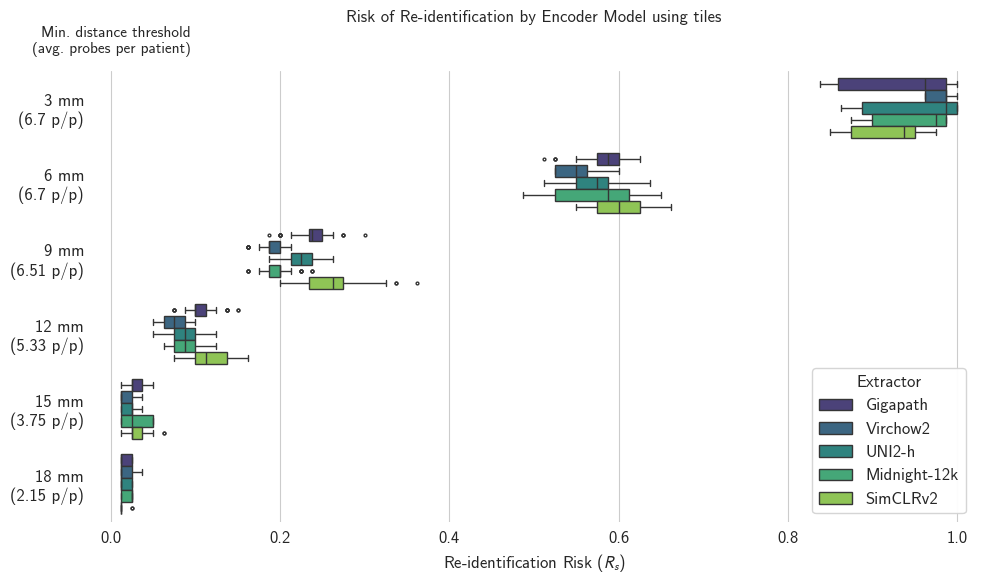

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. ČISTÁ KONFIGURACE (OVERLEAF / LATEX SANS-SERIF LOOK) ---
sns.set_style("whitegrid")

plt.rcParams.update(
    {
        "font.family": "sans-serif",  # Přepnuto z serif na sans-serif
        # Použijeme bezpatkovou verzi Computer Modern (cmss10):
        "font.sans-serif": [
            "Computer Modern Sans Serif",
            "cmss10",
            "Helvetica",
            "Arial",
        ],
        # Zde nastavíme, aby i matematika ($R_s$) používala bezpatkový styl a ladila s textem:
        "mathtext.fontset": "stixsans",
        "font.size": 12,
        "axes.titlesize": 12,
        "axes.labelsize": 12,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
        "legend.title_fontsize": 12,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)

MM_PER_SLICE = 3
MAX_DISTANCE = 6  

method_rename = {
    'vlad_default': 'VLAD',
    'vlad_default_super': 'VLAD Block Pooling',
    'fisher_default': 'Fisher',
    'fisher_default_super': 'Fisher Block Pooling',
    'mean_default': 'Mean',
    'mean_default_super': 'Mean Block Pooling',
}

probe_stats = {
    1: 6.70, 2: 6.70, 3: 6.51, 4: 5.33, 5: 3.75, 6: 2.15
}

df_plot = df_final_dist.copy()
df_plot = df_plot[df_plot['distance'] <= MAX_DISTANCE]
df_plot['encoder'] = df_plot['encoder'].astype(str)

encoder_rename_str = {
    '0': 'Gigapath', '1': 'Virchow2', '2': 'UNI2-h', '3': 'Midnight-12k', '4': 'SimCLRv2'
}

df_plot['method'] = df_plot['method'].map(method_rename).fillna(df_plot['method'])
df_plot['encoder'] = df_plot['encoder'].map(encoder_rename_str).fillna(df_plot['encoder'])

def create_label(dist):
    mm = dist * MM_PER_SLICE
    pp = probe_stats.get(dist, 0)
    return f"{mm:g} mm\n({pp} p/p)"

df_plot['threshold_label'] = df_plot['distance'].apply(create_label)
dist_order = [create_label(d) for d in range(1, MAX_DISTANCE + 1)]

# --- 3. PLOTTING FUNCTION ---
def finalize_plot(ax, title, legend_title):
    # Hlavní nadpis grafu posuneme o kousek výš (pad=35), aby udělal místo pro popisek osy
    ax.set_title(title, pad=35, fontweight='bold')
    ax.set_xlabel("Re-identification Risk ($R_s$)")
    
    # 1. Odstraníme původní ylabel na straně
    ax.set_ylabel("")
    
    # 2. Umístíme nový víceřádkový popisek NAD osu Y
    # Souřadnice x=-0.02 a y=1.02 umísťují text kousíček vlevo a nad samotný graf
    ax.text(
        x=0.11, 
        y=1.03, 
        s="Min. distance threshold\n(avg. probes per patient)",
        transform=ax.transAxes,    # Použije relativní souřadnice grafu (0 až 1)
        rotation=0,                # Horizontálně
        horizontalalignment='right', # Zarovná text k pravému okraji (k ose)
        verticalalignment='bottom',  # Spodek textu bude lícovat s horní hranou
        fontsize=11
    )
    
    # Horizontální popisky hodnot (3 mm, 6 mm...) na Y
    plt.setp(ax.get_yticklabels(), rotation=0, horizontalalignment='right')
    
    # Legenda v pravém dolním rohu
    ax.legend(title=legend_title, loc='lower right', frameon=True, framealpha=0.95, edgecolor='#d3d3d3')
    
    ax.set_xlim(-0.02, 1.02)
    sns.despine(left=True, bottom=True)
    plt.tight_layout()

# GRAF 1: Metody
plt.figure(figsize=(10, 6)) # Kompaktnější rozměr, ideální do šablony book
ax1 = sns.boxplot(
    data=df_plot, x="rs_value", y="threshold_label", hue="method",
    order=dist_order, orient="h", palette="husl", fliersize=2
)
finalize_plot(ax1, "Risk of Re-identification by Aggregation Method using tiles", "Method")

# GRAF 2: Encodery
plt.figure(figsize=(10, 6))
ax2 = sns.boxplot(
    data=df_plot, x="rs_value", y="threshold_label", hue="encoder",
    order=dist_order, orient="h", palette="viridis", fliersize=2
)
finalize_plot(ax2, "Risk of Re-identification by Encoder Model using tiles", "Extractor")

plt.show()

In [ ]:
import os
import urllib.parse
import re
import numpy as np
import pyarrow.parquet as pq
from pathlib import Path
from collections import defaultdict
import pandas as pd

def get_probe_statistics_standalone(base_path, embedding_col="vlad_default", max_dist=10):
    """
    Projde složky a vypočítá statistiku probes per patient s využitím tvé logiky.
    """
    main_path = Path(base_path)
    # Shromažďujeme řezy pro každého pacienta: {patient_id: set(slice_numbers)}
    patient_slices = defaultdict(set)
    
    # Najdeme všechny parquet soubory v podadresářích
    parquet_files = list(main_path.glob("**/*.parquet"))
    print(f"Nalezeno {len(parquet_files)} souborů. Zahajuji parsování...")

    for pf in parquet_files:
        try:
            # Načteme jen sloupec s názvem souboru pro rychlost (embedding col tu nepotřebujeme)
            table = pq.read_table(pf, columns=["__filename"])
            
            for i in range(len(table)):
                raw_filename = table.column("__filename")[i].as_py()
                decoded_path = urllib.parse.unquote(raw_filename)
                filename = decoded_path.split('/')[-1].upper()
                
                # --- TVOJE FILTRY ---
                #bad_markers = []
                bad_markers = ["PSA", "CD34", "D240", "D2-40", "KI67", "ER", "PR", "HER2"]
                if any(m in filename for m in bad_markers): continue
                if re.search(r'(?:VEN|DORS|VENT)\d+-', filename): continue
                    
                match = re.search(r'(?:VEN|DORS|VENT)[-]?(\d{1,2})', filename)
                if match:
                    num = int(match.group(1))
                    if num > 13: continue
                        
                    # Pacient ID ze složky (předposlední část cesty)
                    parts = decoded_path.split('/')
                    p_id = parts[-2] if len(parts) > 1 else "unknown"
                    
                    patient_slices[p_id].add(num)
        except Exception as e:
            print(f"Chyba při čtení {pf.name}: {e}")
            continue

    # --- VLASTNÍ VÝPOČET STATISTIKY ---
    total_patients = len(patient_slices)
    results = []

    for d in range(1, max_dist + 1):
        total_probes_at_dist = 0
        
        for pid, slices in patient_slices.items():
            probes_for_this_patient = 0
            for s in slices:
                # Sonda pro vzdálenost d existuje, pokud má pacient řez o d dál nebo blíž
                if (s + d) in slices or (s - d) in slices:
                    probes_for_this_patient += 1
            total_probes_at_dist += probes_for_this_patient
        
        avg_probes = total_probes_at_dist / total_patients if total_patients > 0 else 0
        results.append({
            "Distance": d,
            "Total Probes": total_probes_at_dist,
            "Probes per Patient": round(avg_probes, 2)
        })

    return pd.DataFrame(results)

# --- KONFIGURACE ---
# Cesta k jednomu konkrétnímu runu/encoderu pro ukázku
BASE_PATH = "/data/fs201053/jb88526/privagams_enc0_mpp10_enhanced_slides_v5/run_seed_42/"

if os.path.exists("/home/jb88526/similarity/data/probe_statistics.csv"):
    stats_df = pd.read_csv("/home/jb88526/similarity/data/probe_statistics.csv")
else:
    stats_df = get_probe_statistics_standalone(BASE_PATH)
    stats_df.to_csv("/home/jb88526/similarity/data/probe_statistics.csv", index=False)

print("\n--- STATISTIKA PROBES PER PATIENT (OČIŠTĚNÁ DATA) ---")
print(stats_df.to_string(index=False))

Nalezeno 560 souborů. Zahajuji parsování...

--- STATISTIKA PROBES PER PATIENT (OČIŠTĚNÁ DATA) ---
 Distance  Total Probes  Probes per Patient
        1           536                6.70
        2           536                6.70
        3           521                6.51
        4           426                5.33
        5           300                3.75
        6           172                2.15
        7            92                1.15
        8            46                0.57
        9            16                0.20
       10             8                0.10


In [78]:
import os
import re
import urllib.parse
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import faiss
import gc
from pathlib import Path
from tqdm import tqdm

# --- KONFIGURACE ---
# Cesta, kam jste uložili výsledky z prvního skriptu
INPUT_PARQUET_DIR = "/data/fs201053/jb88526/tissue_embeddings_full_downscale.parquet" 
MAX_DIST = 10

# Seznam modelů, které máte v parquetu (odpovídá prefixům emb_ v prvním skriptu)
MODELS = ["gigapath", "virchow2", "uni2h", "midnight", "simclrv2"]

def calculate_rs_by_distance(patient_ids, slice_nums, embeddings, max_dist=10):
    """
    Vypočítá Success Rate (Rs) pro různé vzdálenosti řezů d.
    """
    n, dim = embeddings.shape
    if n < 2: return {d: 0.0 for d in range(1, max_dist + 1)}
    
    # Použijeme FAISS pro rychlé hledání sousedů (Inner Product na normalizovaných datech = Cosine Similarity)
    index = faiss.IndexFlatIP(dim)
    faiss.normalize_L2(embeddings)
    index.add(embeddings)
    
    # Hledáme dostatečný počet sousedů, abychom pokryli potenciální shody
    k = min(100, n)
    distances, indices = index.search(embeddings, k)
    
    rs_results = {}
    total_patients = len(set(patient_ids))

    for d in range(1, max_dist + 1):
        vulnerable_patients = set()
        
        for i in range(n):
            current_pid = patient_ids[i]
            current_slice = slice_nums[i]
            
            found_dist_match = False
            for neighbor_idx in indices[i, 1:]:
                # Pokud narazíme na jiného pacienta dřív, než najdeme náš vzdálený řez,
                # útok na tento konkrétní slide selhal (v Top-K je někdo jiný blíž).
                if patient_ids[neighbor_idx] != current_pid:
                    break 
                
                # Pokud je to stejný pacient a vzdálenost řezů odpovídá d
                if abs(slice_nums[neighbor_idx] - current_slice) == d:
                    found_dist_match = True
                    break
            
            if found_dist_match:
                vulnerable_patients.add(current_pid)
        
        rs_results[d] = len(vulnerable_patients) / total_patients if total_patients > 0 else 0.0
        
    return rs_results

def run_analysis(input_dir, models):
    input_path = Path(input_dir)
    # Načtení všech parquet souborů v adresáři (Ray je často ukládá jako sadu souborů)
    p_files = list(input_path.glob("*.parquet")) if input_path.is_dir() else [input_path]
    
    if not p_files:
        print("Nebyly nalezeny žádné Parquet soubory.")
        return pd.DataFrame()

    # Sběr dat napříč všemi soubory
    data_dict = {m: [] for m in models}
    all_pids = []
    all_slices = []

    print(f"Načítám data z {len(p_files)} souborů...")
    for pf in tqdm(p_files):
        try:
            table = pq.read_table(pf)
            df_batch = table.to_pandas()
            
            for _, row in df_batch.iterrows():
                # Extrakce metadat z slide_id (cesty)
                raw_sid = row["slide_id"]
                decoded_path = urllib.parse.unquote(raw_sid)
                filename = decoded_path.split('/')[-1].upper()
                
                # 1. Filtry (stejné jako ve vašem zadání)
                bad_markers = ["PSA", "CD34", "D240", "D2-40", "KI67", "ER", "PR", "HER2"]
                if any(m in filename for m in bad_markers): continue
                if re.search(r'(?:VEN|DORS|VENT)\d+-', filename): continue
                
                # 2. Extrakce čísla řezu (slice number)
                match = re.search(r'(?:VEN|DORS|VENT)[-]?(\d{1,2})', filename)
                if match:
                    s_num = int(match.group(1))
                    if s_num > 13: continue # Omezení podle vašeho kódu
                    
                    # Patient ID - předpokládáme, že je to název nadřazené složky
                    p_id = decoded_path.split('/')[-2]
                    
                    all_pids.append(p_id)
                    all_slices.append(s_num)
                    
                    # Uložení embeddingů pro každý model
                    for m in models:
                        data_dict[m].append(row[f"emb_{m}"])
        except Exception as e:
            print(f"Chyba při zpracování {pf}: {e}")
            continue

    all_results = []
    patient_ids = np.array(all_pids)
    slice_nums = np.array(all_slices)

    # Spuštění FAISS analýzy pro každý model
    for m in models:
        print(f"Počítám Rs pro model: {m}")
        embeddings = np.array(data_dict[m], dtype='float32')
        
        rs_dist_map = calculate_rs_by_distance(patient_ids, slice_nums, embeddings, MAX_DIST)
        
        for d, val in rs_dist_map.items():
            all_results.append({
                "model": m,
                "distance": d,
                "rs_value": val
            })
        
        del embeddings; gc.collect()

    return pd.DataFrame(all_results)

# --- SPUŠTĚNÍ ---
if os.path.exists("/home/jb88526/similarity/data/rs_distance_analysis_thumbnail.csv"):
    df_final = pd.read_csv("/home/jb88526/similarity/data/rs_distance_analysis_thumbnail.csv")
else:
    df_final = run_analysis(INPUT_PARQUET_DIR, MODELS)
    df_final.to_csv("/home/jb88526/similarity/data/rs_distance_analysis_thumbnail.csv", index=False)

print(df_final.head(20))
pivot = df_final.pivot(index='distance', columns='model', values='rs_value')
print("\nSuccess Rate Rs podle vzdálenosti řezů (v %):")
print((pivot * 100).round(2))


       model  distance  rs_value
0   gigapath         1    0.7750
1   gigapath         2    0.3500
2   gigapath         3    0.1625
3   gigapath         4    0.0625
4   gigapath         5    0.0000
5   gigapath         6    0.0125
6   gigapath         7    0.0000
7   gigapath         8    0.0000
8   gigapath         9    0.0125
9   gigapath        10    0.0000
10  virchow2         1    0.6375
11  virchow2         2    0.2750
12  virchow2         3    0.1125
13  virchow2         4    0.0625
14  virchow2         5    0.0125
15  virchow2         6    0.0000
16  virchow2         7    0.0000
17  virchow2         8    0.0000
18  virchow2         9    0.0000
19  virchow2        10    0.0000

Success Rate Rs podle vzdálenosti řezů (v %):
model     gigapath  midnight  simclrv2  uni2h  virchow2
distance                                               
1            77.50     62.50     56.25  85.00     63.75
2            35.00     23.75     22.50  33.75     27.50
3            16.25     10.00     11.

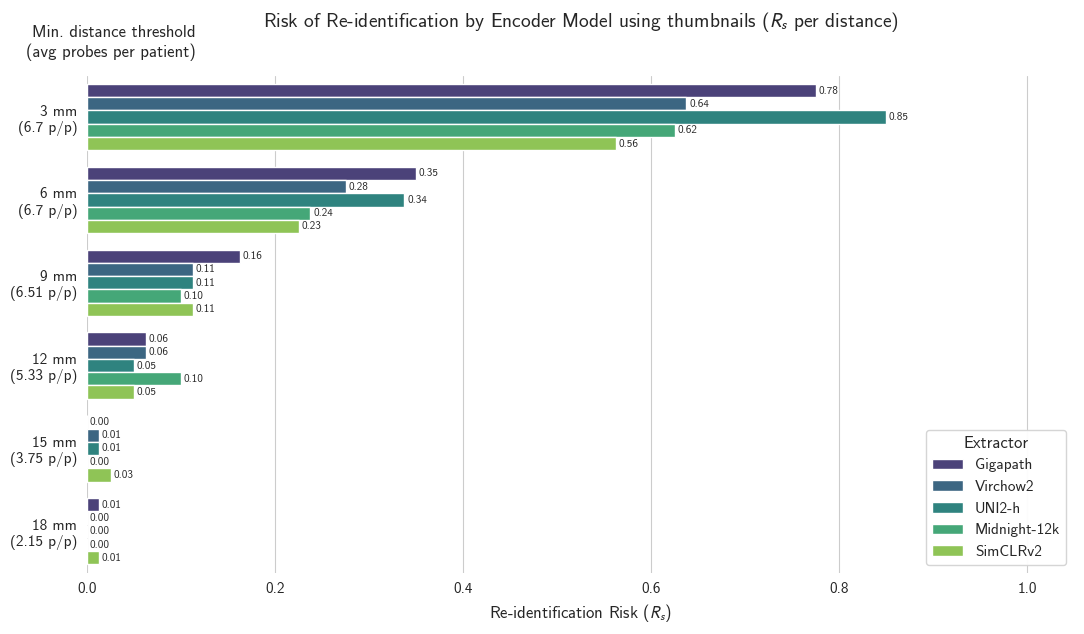

In [79]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# --- 1. GLOBÁLNÍ KONFIGURACE FONTŮ (OVERLEAF / LATEX SANS-SERIF LOOK) ---
sns.set_style("whitegrid")

plt.rcParams.update(
    {
        "font.family": "sans-serif",  # Přepnuto na bezpatkové písmo
        # Bezpatkový Computer Modern font (cmss10) známý z LaTeXu:
        "font.sans-serif": [
            "Computer Modern Sans Serif",
            "cmss10",
            "Helvetica",
            "Arial",
        ],
        # Bezpatková matematika, aby indexy v $R_s$ ladily se zbytkem textu:
        "mathtext.fontset": "stixsans",
        "font.size": 12,  # Základní velikost textů (12 pt)
        "axes.titlesize": 14,  # Velikost hlavního nadpisu
        "axes.labelsize": 12,  # Velikost popisků os
        "xtick.labelsize": 11,  # Velikost čísel na ose X
        "ytick.labelsize": 11,  # Velikost hodnot na ose Y (mm)
        "legend.fontsize": 11,  # Velikost položek v legendě
        "legend.title_fontsize": 12,  # Velikost nadpisu legendy
        "pdf.fonttype": 42,  # TrueType embedding pro bezchybné PDF do závěrečné práce
        "ps.fonttype": 42,
    }
)

MM_PER_SLICE = 3
MAX_DISTANCE = 6

encoder_rename_str = {
    "gigapath": "Gigapath",
    "virchow2": "Virchow2",
    "uni2h": "UNI2-h",
    "midnight": "Midnight-12k",
    "simclrv2": "SimCLRv2",
}

probe_stats = {1: 6.70, 2: 6.70, 3: 6.51, 4: 5.33, 5: 3.75, 6: 2.15}

# --- 2. PŘÍPRAVA DAT ---
# Předpokládá se, že DataFrame `df_final` již existuje ve tvém prostředí
df_plot = df_final.copy()
df_plot["distance"] = df_plot["distance"].astype(int)
df_plot = df_plot[df_plot["distance"] <= MAX_DISTANCE]

# Mapování názvů encoderů
df_plot["model"] = (
    df_plot["model"].astype(str).map(encoder_rename_str).fillna(df_plot["model"])
)


# Vytvoření popisků osy Y (vzdálenost v mm + průměrný počet sond)
def create_label(dist):
    mm = dist * MM_PER_SLICE
    pp = probe_stats.get(dist, 0)
    return f"{mm:g} mm\n({pp} p/p)"


df_plot["threshold_label"] = df_plot["distance"].apply(create_label)
dist_order = [create_label(d) for d in range(1, MAX_DISTANCE + 1)]

# --- 3. VYKRESLOVÁNÍ ---
# Velikost figury upravená pro ideální poměr sloupců v textu práce
plt.figure(figsize=(11, 6.5))

ax = sns.barplot(
    data=df_plot,
    x="rs_value",
    y="threshold_label",
    hue="model",
    order=dist_order,
    orient="h",
    palette="viridis",
)

# --- NASTAVENÍ GRAFU, LEGENDY A POPISKŮ ---
# Větší pad nadpisu (35), aby udělal místo pro text nad osou Y
ax.set_title(
    "Risk of Re-identification by Encoder Model using thumbnails ($R_s$ per distance)",
    pad=35,
    fontweight="bold",
)
ax.set_xlabel("Re-identification Risk ($R_s$)")

# 1. Odstranění starého svislého ylabelu na levé straně
ax.set_ylabel("")

# 2. Umístění nového popisku horizontálně přímo NAD osu Y
ax.text(
    x=0.11,
    y=1.03,
    s="Min. distance threshold\n(avg probes per patient)",
    transform=ax.transAxes,  # Souřadnice relativní k osám grafu (0 až 1)
    rotation=0,  # Dokonale vodorovně
    horizontalalignment="right",  # Zarovnání textu k pravému okraj (k ose)
    verticalalignment="bottom",  # Spodní hrana textu lícuje s horní hranou grafu
)

# Nastavení horizontální orientace pro jednotlivé hodnoty osy Y (3 mm, 6 mm...)
plt.setp(ax.get_yticklabels(), rotation=0, horizontalalignment="right")

# Legenda přesunuta dovnitř do prázdného pravého dolního rohu
ax.legend(
    title="Extractor",
    loc="lower right",
    frameon=True,
    framealpha=0.95,
    edgecolor="#d3d3d3",
)

# Rozsah osy X (přesah na 1.05 dává prostor pro čitelná čísla na koncích sloupců)
plt.xlim(0, 1.05)

# Přidání číselných hodnot přímo na konce sloupců (formát na 2 desetinná místa)
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=2,  # Menší mezera mezi koncem sloupce a číslem
        fontsize=8,  # Zmenšeno z 10 na 8 pt, aby se čísla vešla i k malým sloupcům
    )

# Vyčištění zbytečných tmavých linek okolo grafu pro modernější vzhled
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.savefig("/home/jb88526/similarity/plots/reidentification_thumbnails.png", dpi=300)
plt.show()

# PREPROCESSING CHECK

# TOP-1 R_s attack

# Embedding graphs

In [13]:
enc = ["1", "2"]
mpp = ["10"]

emb_col = [
    "vlad_default",
    "vlad_default_super",
    "fisher_default",
    "fisher_default_super",
]

types = ["enhanced_slides_v4", "rmbg_slides_v4", "rmbg_norm_slides_v4", "rmbg_clahe_slides_v4"]


# Preprocessing

In [74]:
def analyze_preprocessing_seeds_fast(base_path, encoders, preprocessing_methods, aggregation_methods):
    results_data = []
    enc_map = {"1": "Virchow2", "2": "UNI2-h"}
    agg_map = {
        'mean_default': 'Mean', 'mean_default_super': 'Mean Block Pooling',
        'vlad_default': 'VLAD', 'vlad_default_super': 'VLAD Block Pooling',
        'fisher_default': 'Fisher', 'fisher_default_super': 'Fisher Block Pooling'
    }

    # Regulární výrazy předem zkompilované (rychlejší matchování)
    bad_markers_regex = re.compile(r"PSA|CD34|D240|D2-40|KI67|ER|PR|HER2")
    dist_regex = re.compile(r'(?:VEN|DORS|VENT)[-]?(\d{1,2})')
    bad_pos_regex = re.compile(r'(?:VEN|DORS|VENT)\d+-')

    for e_key in encoders:
        for prep in preprocessing_methods:
            main_path = Path(base_path) / f"privagams_enc{e_key}_mpp10_{prep}_pre_check"
            if not main_path.exists(): continue
            
            print(f"\n>>> Zrychlené zpracování: {enc_map.get(e_key, e_key)} | {prep}")
            seed_folders = sorted([d for d in main_path.iterdir() if "run_seed_" in d.name])
            
            for sf in tqdm(seed_folders, desc="Seeds"):
                seed_val = sf.name.split("_")[-1]
                p_files = list(sf.glob("*.parquet"))
                if not p_files: continue

                # 1. NAČTENÍ CELÉHO SEEDU DO JEDNÉ TABULKY
                # Načteme všechny agg sloupce + slide_id najednou
                try:
                    df_seed = pd.concat([pd.read_parquet(pf, columns=aggregation_methods + ["slide_id"]) for pf in p_files])
                except Exception: continue

                # 2. VEKTORIZOVANÉ FILTROVÁNÍ (mnohem rychlejší než loop)
                df_seed['decoded_path'] = df_seed['slide_id'].apply(urllib.parse.unquote)
                df_seed['filename'] = df_seed['decoded_path'].str.split('/').str[-1].str.upper()
                
                # Aplikace filtrů
                mask = ~df_seed['filename'].str.contains(bad_markers_regex) & \
                       ~df_seed['filename'].str.contains(bad_pos_regex)
                
                df_filtered = df_seed[mask].copy()
                
                # Extraxe čísla a Patient ID
                def get_dist_and_pid(row):
                    match = dist_regex.search(row['filename'])
                    if match and int(match.group(1)) <= 13:
                        return int(match.group(1)), row['decoded_path'].split('/')[-2]
                    return None, None

                res = df_filtered.apply(get_dist_and_pid, axis=1, result_type='expand')
                df_filtered['dist'], df_filtered['p_id'] = res[0], res[1]
                
                # Finální shození nevyhovujících řádků
                df_filtered = df_filtered.dropna(subset=['p_id'])
                if df_filtered.empty: continue

                p_ids = df_filtered['p_id'].values

                # 3. VÝPOČET RS PRO VŠECHNY AGREGÁTORY
                for agg_col in aggregation_methods:
                    # Převod listu embeddingů na matici naráz
                    embs = np.stack(df_filtered[agg_col].values).astype('float32')
                    faiss.normalize_L2(embs)
                    
                    rs_val = calculate_rs_pure_python(p_ids, embs)
                    
                    results_data.append({
                        "encoder": enc_map.get(e_key, e_key),
                        "preprocessing": prep,
                        "aggregator": agg_map.get(agg_col, agg_col),
                        "rs_value": rs_val,
                        "seed": seed_val
                    })

                del df_seed, df_filtered; gc.collect()
                        
    return pd.DataFrame(results_data)

# --- SPUŠTĚNÍ ---
PATH = "/data/fs201053/jb88526/"
ENC = ["1", "2"]
PREPROCESSING = ["rmbg", "rmbg_norm", "rmbg_clahe", "enhanced"]
AGGREGATORS = ["mean_default", "mean_default_super", "vlad_default", "vlad_default_super", "fisher_default", "fisher_default_super"] # Přidej sloupce, které máš v parquetech

if os.path.exists("/home/jb88526/similarity/data/vysledky_20_seeds_patient_filter_pre.csv"):
    df_results = pd.read_csv("/home/jb88526/similarity/data/vysledky_20_seeds_patient_filter_pre.csv")
else:
    df_results = analyze_preprocessing_seeds_fast(PATH, ENC, PREPROCESSING, AGGREGATORS)
    df_results.to_csv("/home/jb88526/similarity/data/vysledky_20_seeds_patient_filter_pre.csv", index=False)

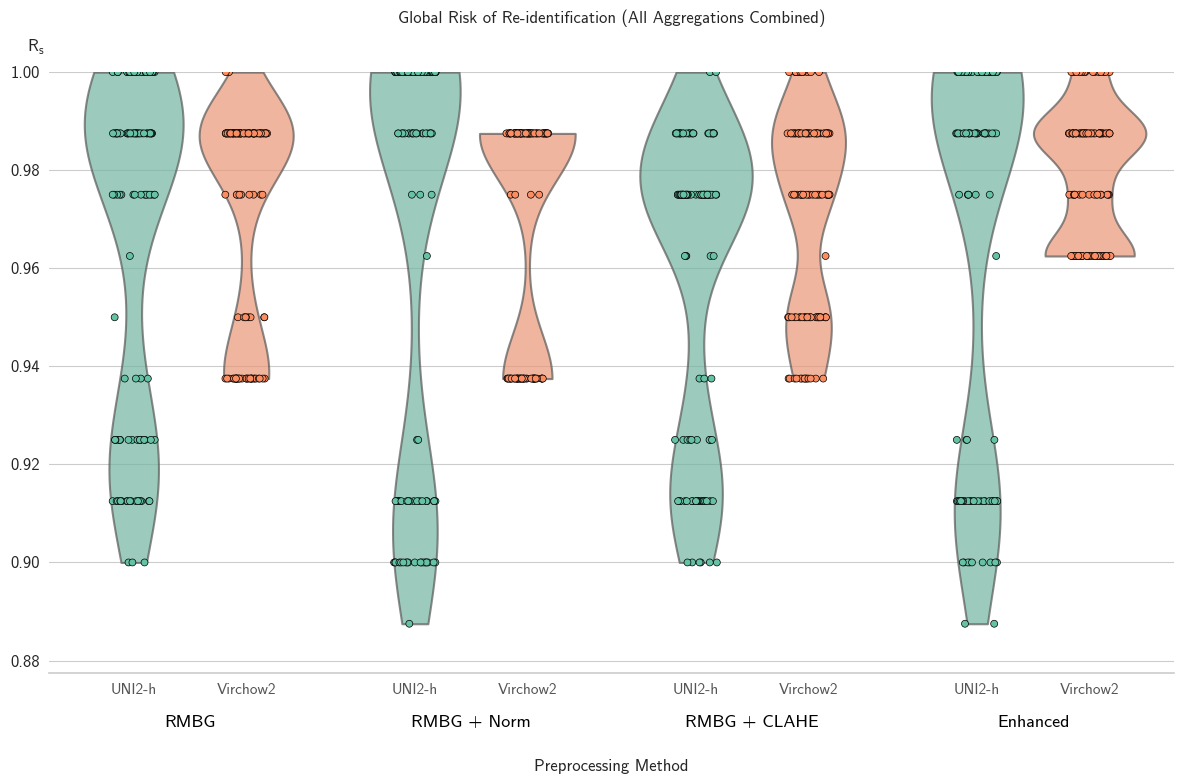

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns


def plot_global_preprocessing_impact(df):
    # --- MOŽNOST PŘUPSÁNÍ METOD PREPROCESSINGU (ENHANCERŮ) ---
    # Sem si dopiš cokoli potřebuješ přejmenovat: {"původní_z_dat": "nový_pěkný_název"}
    preprocessing_mapping = {
        "rmbg": "RMBG",
        "rmbg_norm": "RMBG + Norm",
        "rmbg_clahe": "RMBG + CLAHE",
        "enhanced": "Enhanced"
    }
    
    # Práce s kopií dat
    df_plot = df.copy()

    # --- GLOBÁLNÍ KONFIGURACE FONTŮ (STIXSANS) ---
    sns.set_style("whitegrid")
    plt.rcParams.update(
        {
            "font.family": "sans-serif",
            "font.sans-serif": [
                "Computer Modern Sans Serif",
                "cmss10",
                "Helvetica",
                "Arial",
            ],
            "mathtext.fontset": "stixsans",
            "font.size": 12,
            "axes.titlesize": 12,
            "axes.labelsize": 12,
            "xtick.labelsize": 11,   # Mírně menší pro sub-labely enkodérů
            "ytick.labelsize": 12,
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
        }
    )

    plt.figure(figsize=(12, 8))

    # Definice přesného pořadí enkodérů na základě dat, aby správně seděly barvy s paletou Set2
    encoder_order = sorted(df_plot["encoder"].unique())

    # 1. VYKRESLENÍ VIOLIN PLOTU (Bez globální legendy)
    ax = sns.violinplot(
        data=df_plot,
        x="preprocessing",
        y="rs_value",
        hue="encoder",
        hue_order=encoder_order,  # Fixní pořadí pro správné párování barev
        palette="Set2",       
        alpha=0.7,            
        linewidth=1.5,
        inner="quart",        # Vykreslí linky, které hned pročistíme na medián
        cut=0,                
        legend=False,         
    )

    # TRIK PRO JEDINOU MEDIÁNOVOU ČÁRU
    for line in ax.lines:
        if line.get_linestyle() != "-":
            line.set_visible(False)
        else:
            line.set_linewidth(2.0)
            line.set_color("#333333")

    # 2. VYKRESLENÍ SCATTERPLOTU (Stripplot)
    sns.stripplot(
        data=df_plot,
        x="preprocessing",
        y="rs_value",
        hue="encoder",
        hue_order=encoder_order,  # Fixní pořadí i pro tečky
        palette="Set2",       
        size=5,               
        alpha=1.0,            
        jitter=0.15,          
        dodge=True,           
        edgecolor="black",    
        linewidth=0.5,        
        legend=False,         
        ax=ax
    )

    # Načtení původních kategorií preprocessingu z osy X
    preprocessing_categories = [label.get_text() for label in ax.get_xticklabels()]

    # --- 3. ČISTÉ A UHLAZENÉ ZAROVNÁNÍ OSY X ---
    # Nastavíme enkodéry (sub-ticks) jako hlavní popisky osy X (těsně pod čáru osy)
    sub_tick_positions = []
    sub_tick_labels = []
    for idx in range(len(preprocessing_categories)):
        sub_tick_positions.extend([idx - 0.2, idx + 0.2])
        sub_tick_labels.extend(encoder_order)

    ax.set_xticks(sub_tick_positions)
    ax.set_xticklabels(sub_tick_labels, color="#555555")

    # Hlavní názvy preprocessing metod (přejmenované pomocí slovníku) pod každou dvojici
    for idx, cat_name in enumerate(preprocessing_categories):
        # Pokud je název ve slovníku, přepíše se, jinak zůstane původní
        display_name = preprocessing_mapping.get(cat_name, cat_name)
        
        ax.text(
            x=idx,
            y=-0.07,  # Pozice těsně pod enkodéry
            s=display_name,
            transform=ax.get_xaxis_transform(), # Použije X z dat, ale Y z osy
            horizontalalignment="center",
            verticalalignment="top",
            fontsize=13,
            fontweight="bold",
            color="black"
        )

    # 4. FORMÁTOVÁNÍ OSTATNÍCH POPISKŮ
    ax.set_title(
        "Global Risk of Re-identification (All Aggregations Combined)",
        pad=35,
        fontweight="bold"
    )
    # Posuneme hlavní název osy dostatečně nízko, aby udělal prostor pro sub-popisky
    ax.set_xlabel("Preprocessing Method", labelpad=45)
    ax.set_ylabel("")

    # Triková aplikace R_s podél osy Y
    ax.text(
        x=-0.01, y=1.03, s="R",
        transform=ax.transAxes, horizontalalignment="right", verticalalignment="bottom",
        fontsize=12, fontweight="bold",
    )
    ax.text(
        x=-0.005, y=1.025, s="s",
        transform=ax.transAxes, horizontalalignment="right", verticalalignment="bottom",
        fontsize=9, fontweight="bold",
    )

    plt.ylim(df_plot["rs_value"].min() - 0.01, 1.00)
    
    sns.despine(top=True, right=True, left=True, bottom=False)
    ax.spines['bottom'].set_color('#cccccc')
    ax.spines['bottom'].set_linewidth(1.2)
    
    plt.tight_layout()
    
    plt.savefig("/home/jb88526/similarity/plots/preprocessing_graph.png", dpi=300, bbox_inches='tight')
    plt.show()

# Spuštění
plot_global_preprocessing_impact(df_results)

# MPP

In [61]:
import os
import re
import urllib.parse
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import faiss
import gc
from pathlib import Path
from tqdm import tqdm

def analyze_mpp_seeds_fast(base_path, encoders, mpp_values, aggregation_methods):
    results_data = []
    enc_map = {"1": "Virchow2", "2": "UNI2-h"}
    agg_map = {
        'mean_default': 'Mean', 'mean_default_super': 'Mean Block Pooling',
        'vlad_default': 'VLAD', 'vlad_default_super': 'VLAD Block Pooling',
        'fisher_default': 'Fisher', 'fisher_default_super': 'Fisher Block Pooling'
    }

    # Regulární výrazy předem zkompilované (rychlejší matchování)
    bad_markers_regex = re.compile(r"PSA|CD34|D240|D2-40|KI67|ER|PR|HER2")
    dist_regex = re.compile(r'(?:VEN|DORS|VENT)[-]?(\d{1,2})')
    bad_pos_regex = re.compile(r'(?:VEN|DORS|VENT)\d+-')

    for e_key in encoders:
        for mpp in mpp_values:
            main_path = Path(base_path) / f"privagams_enc{e_key}_mpp{mpp}_enhanced_mpp_check"
            if not main_path.exists(): continue

            print(f"\n>>> Zrychlené zpracování: {enc_map.get(e_key, e_key)} | {mpp} MPP")
            seed_folders = sorted([d for d in main_path.iterdir() if "run_seed_" in d.name])
            
            for sf in tqdm(seed_folders, desc="Seeds"):
                seed_val = sf.name.split("_")[-1]
                p_files = list(sf.glob("*.parquet"))
                if not p_files: continue

                # 1. NAČTENÍ CELÉHO SEEDU DO JEDNÉ TABULKY
                # Načteme všechny agg sloupce + slide_id najednou
                try:
                    df_seed = pd.concat([pd.read_parquet(pf, columns=aggregation_methods + ["slide_id"]) for pf in p_files])
                except Exception: continue

                # 2. VEKTORIZOVANÉ FILTROVÁNÍ (mnohem rychlejší než loop)
                df_seed['decoded_path'] = df_seed['slide_id'].apply(urllib.parse.unquote)
                df_seed['filename'] = df_seed['decoded_path'].str.split('/').str[-1].str.upper()
                
                # Aplikace filtrů
                mask = ~df_seed['filename'].str.contains(bad_markers_regex) & \
                       ~df_seed['filename'].str.contains(bad_pos_regex)
                
                df_filtered = df_seed[mask].copy()
                
                # Extraxe čísla a Patient ID
                def get_dist_and_pid(row):
                    match = dist_regex.search(row['filename'])
                    if match and int(match.group(1)) <= 13:
                        return int(match.group(1)), row['decoded_path'].split('/')[-2]
                    return None, None

                res = df_filtered.apply(get_dist_and_pid, axis=1, result_type='expand')
                df_filtered['dist'], df_filtered['p_id'] = res[0], res[1]
                
                # Finální shození nevyhovujících řádků
                df_filtered = df_filtered.dropna(subset=['p_id'])
                if df_filtered.empty: continue

                p_ids = df_filtered['p_id'].values

                # 3. VÝPOČET RS PRO VŠECHNY AGREGÁTORY
                for agg_col in aggregation_methods:
                    # Převod listu embeddingů na matici naráz
                    embs = np.stack(df_filtered[agg_col].values).astype('float32')
                    faiss.normalize_L2(embs)
                    
                    rs_val = calculate_rs_pure_python(p_ids, embs)
                    
                    results_data.append({
                        "encoder": enc_map.get(e_key, e_key),
                        "mpp": mpp,
                        "aggregator": agg_map.get(agg_col, agg_col),
                        "rs_value": rs_val,
                        "seed": seed_val
                    })

                del df_seed, df_filtered; gc.collect()
                        
    return pd.DataFrame(results_data)

# --- SPUŠTĚNÍ ---
PATH = "/data/fs201053/jb88526/"
ENC = ["1", "2"]
MPP = ["05","10", "20"]
AGGREGATORS = ["mean_default", "mean_default_super", "vlad_default", "vlad_default_super", "fisher_default", "fisher_default_super"] # Přidej sloupce, které máš v parquetech

if os.path.exists("/home/jb88526/similarity/data/vysledky_20_seeds_mpp_filter.csv"):
    df_results = pd.read_csv("/home/jb88526/similarity/data/vysledky_20_seeds_mpp_filter.csv")
else:
    df_results = analyze_mpp_seeds_fast(PATH, ENC, MPP, AGGREGATORS)
    df_results.to_csv("/home/jb88526/similarity/data/vysledky_20_seeds_mpp_filter.csv", index=False)

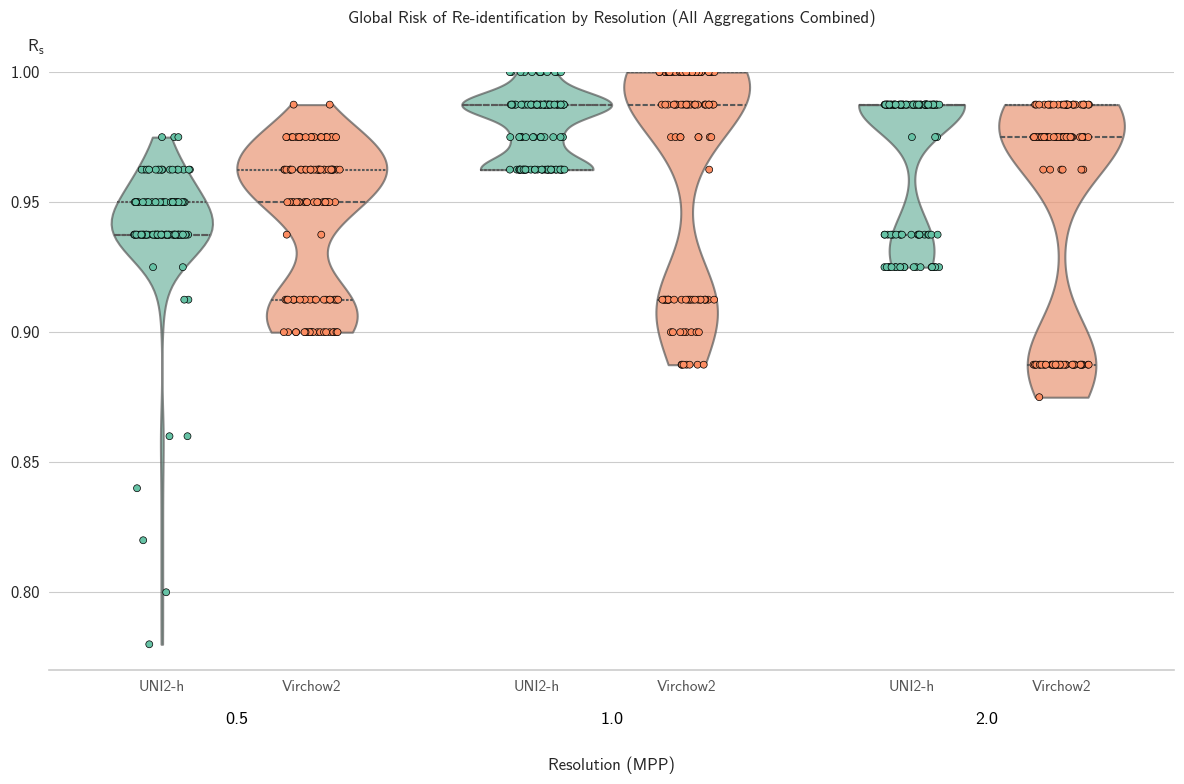

In [72]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def plot_global_mpp_impact(df):
    # Práce s kopií dat, abychom nezměnili původní DataFrame
    df_plot = df.copy()

    # --- ROBUSTNÍ OPRAVA DAT ---
    df_plot["mpp"] = df_plot["mpp"].astype(str).str.replace(".0", "", regex=False)
    df_plot["mpp"] = df_plot["mpp"].str.replace(".", "", regex=False)
    df_plot["mpp"] = df_plot["mpp"].apply(lambda x: "05" if x == "5" else x)
    # ---------------------------

    # --- GLOBÁLNÍ KONFIGURACE FONTŮ (STIXSANS) ---
    sns.set_style("whitegrid")
    plt.rcParams.update(
        {
            "font.family": "sans-serif",
            "font.sans-serif": [
                "Computer Modern Sans Serif",
                "cmss10",
                "Helvetica",
                "Arial",
            ],
            "mathtext.fontset": "stixsans",
            "font.size": 12,
            "axes.titlesize": 12,
            "axes.labelsize": 12,
            "xtick.labelsize": 11,   # Mírně menší pro sub-labely
            "ytick.labelsize": 12,
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
        }
    )

    plt.figure(figsize=(12, 8))

    # Definice pořadí kategorií
    mpp_order = ["05", "10", "20"]

    # 1. VYKRESLENÍ VIOLIN PLOTU (Bez globální legendy)
    ax = sns.violinplot(
        data=df_plot,
        x="mpp",
        y="rs_value",
        hue="encoder",
        palette="Set2",
        alpha=0.7,
        linewidth=1.5,
        inner="quart",
        cut=0,
        order=mpp_order,
        legend=False,
    )

    # 2. VYKRESLENÍ SCATTERPLOTU (Stripplot)
    sns.stripplot(
        data=df_plot,
        x="mpp",
        y="rs_value",
        hue="encoder",
        palette="Set2",
        size=5,
        alpha=1,
        jitter=0.15,
        dodge=True,
        order=mpp_order,
        legend=False,
        edgecolor="black",
        linewidth=0.5,
        ax=ax,
    )

    # Získání unikátních enkodérů
    encoders = sorted(df_plot["encoder"].unique())

    # --- 3. ČISTÉ A UHLAZENÉ ZAROVNÁNÍ OSY X ---
    # Vygenerujeme pozice pro sub-popisky enkodérů (středy rozdělených houslí: idx - 0.2 a idx + 0.2)
    sub_tick_positions = []
    sub_tick_labels = []
    for idx in range(len(mpp_order)):
        sub_tick_positions.extend([idx - 0.2, idx + 0.2])
        sub_tick_labels.extend(encoders)

    # Nastavíme enkodéry jako primární popisky osy X (budou těsně pod čárou osy)
    ax.set_xticks(sub_tick_positions)
    ax.set_xticklabels(sub_tick_labels, color="#555555")

    # Hlavní rozlišení (0.5, 1.0, 2.0) umístíme elegantně jako velký text pod každou dvojici
    mpp_labels = {"05": "0.5", "10": "1.0", "20": "2.0"}
    for idx, mpp_cat in enumerate(mpp_order):
        ax.text(
            x=idx,
            y=-0.07,  # Pozice relativní vůči transAxes (těsně pod enkodéry)
            s=mpp_labels[mpp_cat],
            transform=ax.get_xaxis_transform(), # Použije X z dat, ale Y z osy
            horizontalalignment="center",
            verticalalignment="top",
            fontsize=13,
            fontweight="bold",
            color="black"
        )

    # 4. FORMÁTOVÁNÍ OSTATNÍCH POPISKŮ
    ax.set_title(
        "Global Risk of Re-identification by Resolution (All Aggregations Combined)",
        pad=35,
        fontweight="bold",
    )
    # Posuneme hlavní název osy o kousek níž, aby udělal prostor pro hierarchické popisky
    ax.set_xlabel("Resolution (MPP)", labelpad=45)
    ax.set_ylabel("")

    # Triková aplikace R_s nad osu Y
    ax.text(
        x=-0.01, y=1.03, s="R",
        transform=ax.transAxes, horizontalalignment="right", verticalalignment="bottom",
        fontsize=12, fontweight="bold",
    )
    ax.text(
        x=-0.005, y=1.025, s="s",
        transform=ax.transAxes, horizontalalignment="right", verticalalignment="bottom",
        fontsize=9, fontweight="bold",
    )

    # Původní rozsah osy Y přesně do 1.00
    plt.ylim(df_plot["rs_value"].min() - 0.01, 1.00)

    # UHLAVNÍ ZMĚNA: Odstraníme top, right, left, ale spodní čáru (bottom) necháme zapnutou!
    sns.despine(top=True, right=True, left=True, bottom=False)
    
    # Nastavíme barvu spodní linky na jemnou šedou, aby ladila s mřížkou whitegrid
    ax.spines['bottom'].set_color('#cccccc')
    ax.spines['bottom'].set_linewidth(1.2)

    plt.tight_layout()
    plt.savefig(
        "/home/jb88526/similarity/plots/mpp_graph.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

plot_global_mpp_impact(df_results)

# Synthetic data

In [ ]:
import os
import glob
import pandas as pd
import numpy as np
import faiss
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor

# --- 1. RYCHLÉ NAČÍTÁNÍ ---

def read_single_parquet(f_orig):
    f_gen = f_orig.replace("orig_embeddings", "gen_embeddings")
    if not os.path.exists(f_gen): return None
    p_id = os.path.basename(os.path.dirname(os.path.dirname(f_orig)))
    try:
        df_o = pd.read_parquet(f_orig)
        df_g = pd.read_parquet(f_gen)
        return p_id, {
            'orig': np.stack(df_o['embedding'].values).astype('float32'),
            'gen': np.stack(df_g['embedding'].values).astype('float32')
        }
    except: return None

def load_data_parallel(root_path, encoder, variant):
    search_pattern = f"**/orig_embeddings_{encoder}_{variant}.parquet"
    orig_files = glob.glob(os.path.join(root_path, search_pattern), recursive=True)
    patient_data = {}
    with ThreadPoolExecutor(max_workers=8) as executor:
        results = list(tqdm(executor.map(read_single_parquet, orig_files), 
                           total=len(orig_files), desc=f"Loading {encoder}-{variant}"))
    for res in results:
        if res:
            p_id, data = res
            patient_data[p_id] = data
    return patient_data

# --- 2. EXTRÉMNĚ RYCHLÁ ANALÝZA ---

ROOT_PATH = "/data/fs201053/jb88526/reidentification_test_complete_v2"
ENCODERS = ["gigapath", "virchow2", "uni2h", "midnight12k", "simclrv2"]
VARIANTS = ["raw", "norm"]

PATIENT_COUNTS = [5, 10, 20, 40, 60, 80]
TILE_COUNTS = [1, 5, 10, 50, 100, 250, 500]

all_scaling_p = []
all_scaling_t = []

# Nastavení vláken pro FAISS (vytíží tvé CPU na max)
faiss.omp_set_num_threads(8)

for enc in ENCODERS:
    for var in VARIANTS:
        data = load_data_parallel(ROOT_PATH, enc, var)
        pids = sorted(list(data.keys()))
        if not pids: continue
        
        print(f"\n>>> Spouštím optimalizovaný search: {enc} | {var}")

        # --- PŘÍPRAVA MATIC PRO CELOU SADU (80 pacientů) ---
        # orig: [P * T, Dim], gen: [P * T, Dim]
        full_orig = np.concatenate([data[p]['orig'] for p in pids])
        full_gen = np.concatenate([data[p]['gen'] for p in pids])
        
        # Indexy pacientů pro každou dlaždici (např. 0,0,0...1,1,1...)
        # Musíme pamatovat, kolik dlaždic má každý pacient (může se lišit, i když cílíš na 500)
        o_pids_idx = np.concatenate([np.full(len(data[p]['orig']), i) for i, p in enumerate(pids)])
        g_pids_idx = np.concatenate([np.full(len(data[p]['gen']), i) for i, p in enumerate(pids)])

        # --- JEDINÝ TĚŽKÝ VÝPOČET ---
        faiss.normalize_L2(full_orig)
        faiss.normalize_L2(full_gen)
        
        index = faiss.IndexFlatIP(full_orig.shape[1])
        index.add(full_orig)
        
        # Vyhledáme Top-5 pro ÚPLNĚ VŠECHNY dlaždice naráz
        _, all_indices = index.search(full_gen, 5) 
        # all_indices: [Celkový_počet_query, 5] - obsahuje indexy do full_orig

        # --- ANALÝZA 1: SCALING PATIENTS (Sub-sampling výsledků) ---
        for n in tqdm(PATIENT_COUNTS, desc="Scaling Patients"):
            # Maska pro query: bereme jen dlaždice prvních n pacientů
            q_mask = g_pids_idx < n
            current_g_pids = g_pids_idx[q_mask]
            
            # Z výsledků searchu vybereme jen řádky pro tyto query
            res_indices = all_indices[q_mask]
            
            # Převedeme indexy sousedů v galerii na ID pacientů
            neighbor_pids = o_pids_idx[res_indices]
            
            # Výpočet hitů (Top-1 a Top-5)
            t1 = np.sum(neighbor_pids[:, 0] == current_g_pids)
            t5 = np.sum(np.any(neighbor_pids == current_g_pids[:, None], axis=1))
            
            all_scaling_p.append({
                "Encoder": enc, "Var": var, "N_Patients": n, 
                "Top1": (t1 / len(current_g_pids)) * 100,
                "Top5": (t5 / len(current_g_pids)) * 100
            })

        # --- ANALÝZA 2: EXTRÉMNĚ RYCHLÝ SCALING TILES ---
        # Použijeme už hotový 'all_indices' z předchozího kroku, 
        # ale musíme vědět, kolikátá dlaždice to u pacienta je.
        
        # Vytvoříme pole, které říká: "toto je n-tá dlaždice daného pacienta"
        tile_order_idx = np.concatenate([np.arange(len(data[p]['orig'])) for p in pids])
        
        # Abychom měli jistotu, že v omezené galerii (např. jen 1 dlaždice) 
        # najdeme správného pacienta, musíme v původním velkém searchi 
        # hledat více sousedů (k=500 místo k=5).
        print("Provádím hloubkový search pro analýzu dlaždic (k=500)...")
        _, deep_indices = index.search(full_gen, 500) 

        for t in tqdm(TILE_COUNTS, desc="Scaling Tiles"):
            # res_indices: [N_gen, 500]
            # neighbor_pids: ID pacientů pro všech 500 sousedů
            neighbor_pids = o_pids_idx[deep_indices]
            
            # neighbor_tile_orders: Pořadí dlaždic pro všech 500 sousedů
            neighbor_tile_orders = tile_order_idx[deep_indices]
            
            # KLÍČOVÁ MASKA: Soused je platný, jen pokud jeho pořadí <= t
            valid_mask = neighbor_tile_orders < t
            
            # Pro každou query najdeme index prvního (Top-1) a jakéhokoli (Top-5) 
            # platného souseda, který odpovídá ID query pacienta
            
            t1_hits = 0
            t5_hits = 0
            
            for i in range(len(g_pids_idx)):
                q_pid = g_pids_idx[i]
                # Platní sousedé pro tuto konkrétní query v omezené galerii 't'
                row_pids = neighbor_pids[i][valid_mask[i]]
                
                if len(row_pids) > 0:
                    if row_pids[0] == q_pid: t1_hits += 1
                    if np.any(row_pids[:5] == q_pid): t5_hits += 1
            
            all_scaling_t.append({
                "Encoder": enc, "Var": var, "N_Tiles": t, 
                "Top1": (t1_hits / len(g_pids_idx)) * 100,
                "Top5": (t5_hits / len(g_pids_idx)) * 100
            })

all_scaling_p_df = pd.DataFrame(all_scaling_p)
all_scaling_t_df = pd.DataFrame(all_scaling_t)
all_scaling_p_df.to_csv("/home/jb88526/similarity/data/scaling_patients_results.csv", index=False)
all_scaling_t_df.to_csv("/home/jb88526/similarity/data/scaling_tiles_results.csv", index=False)

Loading gigapath-raw: 100%|██████████| 80/80 [00:01<00:00, 79.47it/s]



>>> Spouštím optimalizovaný search: gigapath | raw


Scaling Patients: 100%|██████████| 6/6 [00:00<00:00, 1244.54it/s]


Provádím hloubkový search pro analýzu dlaždic (k=500)...


Loading gigapath-norm: 100%|██████████| 80/80 [00:01<00:00, 58.31it/s]


...

Loading virchow2-norm: 100%|██████████| 80/80 [00:02<00:00, 34.93it/s]



>>> Spouštím optimalizovaný search: virchow2 | norm


Scaling Patients: 100%|██████████| 6/6 [00:00<00:00, 1146.77it/s]


Provádím hloubkový search pro analýzu dlaždic (k=500)...


Scaling Tiles: 100%|██████████| 7/7 [00:01<00:00,  3.93it/s]


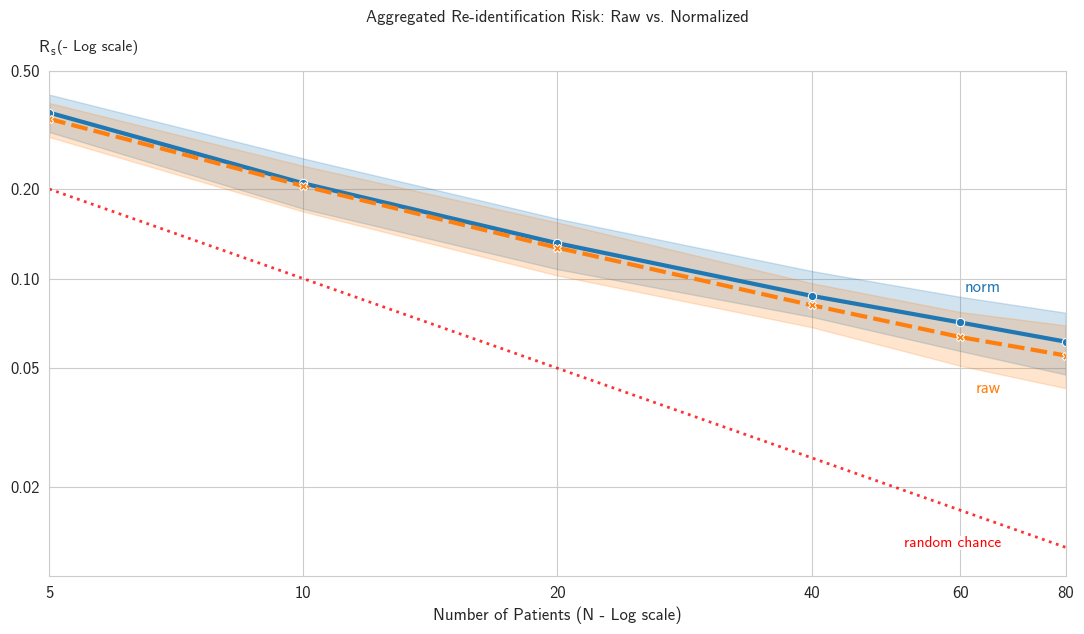

In [82]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.ticker import NullFormatter, ScalarFormatter

# --- 1. DATA LOADING AND PREPARATION ---
df_p = pd.read_csv("/home/jb88526/similarity/data/scaling_patients_all.csv")

# Convert percentage to Success Rate (Rs)
df_p["Top1"] = df_p["Top1"] / 100
PATIENT_COUNTS = np.sort(df_p["N_Patients"].unique())

# --- 2. IDENTICKÁ KONFIGURACE FONTŮ (STIXSANS) ---
sns.set_style("whitegrid")
plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": [
            "Computer Modern Sans Serif",
            "cmss10",
            "Helvetica",
            "Arial",
        ],
        "mathtext.fontset": "stixsans",
        "font.size": 12,
        "axes.titlesize": 12,
        "axes.labelsize": 12,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
        "legend.title_fontsize": 12,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "figure.facecolor": "white",
    }
)

# --- 3. VISUALIZATION ---
fig, ax = plt.subplots(figsize=(11, 6.5))

# Vykreslení křivek (vypnutá legenda)
sns.lineplot(
    data=df_p,
    x="N_Patients",
    y="Top1",
    hue="Var",
    style="Var",
    markers=True,
    linewidth=3,
    errorbar=("ci", 95),
    legend=False, 
    ax=ax,
)

# Set LOG scale
ax.set_xscale("log")
ax.set_yscale("log")

# Axis formatting
ax.set_xticks(PATIENT_COUNTS)
ax.get_xaxis().set_major_formatter(ScalarFormatter())
ax.get_xaxis().set_minor_formatter(NullFormatter())

ax.set_yticks([0.02, 0.05, 0.1, 0.2, 0.5])
ax.get_yaxis().set_major_formatter(ScalarFormatter())
ax.get_yaxis().set_minor_formatter(NullFormatter())

# Random Chance baseline
ax.plot(
    PATIENT_COUNTS,
    1 / PATIENT_COUNTS,
    color="red",
    linestyle=":",
    linewidth=2,
    alpha=0.8,
)

# --- 4. FORMÁTOVÁNÍ POPISKŮ OS ---
ax.set_title(
    "Aggregated Re-identification Risk: Raw vs. Normalized",
    pad=35,
    fontweight="bold",
)
ax.set_xlabel("Number of Patients (N - Log scale)")
ax.set_ylabel("") 

# R_s indexy bez mezer
ax.text(
    x=0.0, y=1.03, s="R",
    transform=ax.transAxes, horizontalalignment="right", verticalalignment="bottom",
    fontsize=12, fontweight="bold",
)
ax.text(
    x=0.006, y=1.025, s="s",
    transform=ax.transAxes, horizontalalignment="right", verticalalignment="bottom",
    fontsize=9, fontweight="bold",
)
ax.text(
    x=0.008, y=1.03, s="(- Log scale)",
    transform=ax.transAxes, horizontalalignment="left", verticalalignment="bottom",
    fontsize=11,
)

# --- 5. POPISKY JEDEN NAD ČÁROU, DRUHÝ POD ČÁROU ---
max_real_x = df_p["N_Patients"].max()
lines = [l for l in ax.get_lines() if l.get_color() != "red"]

# Zjistíme přesné koncové hodnoty pro obě varianty
y_raw = df_p[(df_p["Var"] == "raw") & (df_p["N_Patients"] == max_real_x)]["Top1"].mean()
y_norm = df_p[(df_p["Var"] == "norm") & (df_p["N_Patients"] == max_real_x)]["Top1"].mean()

# Podle toho, která je reálně výš, určíme barvy prvků v poli lines
# (Seaborn je řadí podle abecedy: 'norm' pak 'raw')
color_norm = lines[0].get_color()
color_raw = lines[1].get_color()

# POPISEK 1: "raw" (je výše, dáme ho NAD čáru -> verticalalignment='bottom')
ax.text(
    x=max_real_x - 13,        # Těsně za konec čáry
    y=y_raw - 0.02,
    s="raw",
    horizontalalignment="right",
    fontsize=12,
    fontweight="bold",
    color=color_raw,
    bbox=dict(facecolor="white", alpha=0.5, edgecolor="none", pad=0)
)

# POPISEK 2: "norm" (je níže, dáme ho POD čáru -> verticalalignment='top')
ax.text(
    x=max_real_x - 13,        # Těsně za konec čáry
    y=y_norm+0.035,
    s="norm",
    horizontalalignment="right",
    fontsize=12,
    fontweight="bold",
    color=color_norm,
    bbox=dict(facecolor="white", alpha=0.5, edgecolor="none", pad=0)
)

# POPISEK 3: Random Chance (pod čáru, aby nepřekážela)
random_chance_at_max = 1 / max_real_x
ax.text(
    x=max_real_x - 13,
    y=random_chance_at_max,
    s="random chance",
    horizontalalignment="right",
    fontsize=11,
    color="red",
    bbox=dict(facecolor="white", alpha=0.9, edgecolor="none", pad=0)
)

# Nastavení limitů os, aby texty vpravo měly dost místa
ax.set_xlim(df_p["N_Patients"].min(), max_real_x)
plt.ylim(0.01, 0.5)
plt.tight_layout()
plt.savefig("/home/jb88526/similarity/plots/synth-raw-norm.png", dpi=300, bbox_inches="tight")
plt.show()

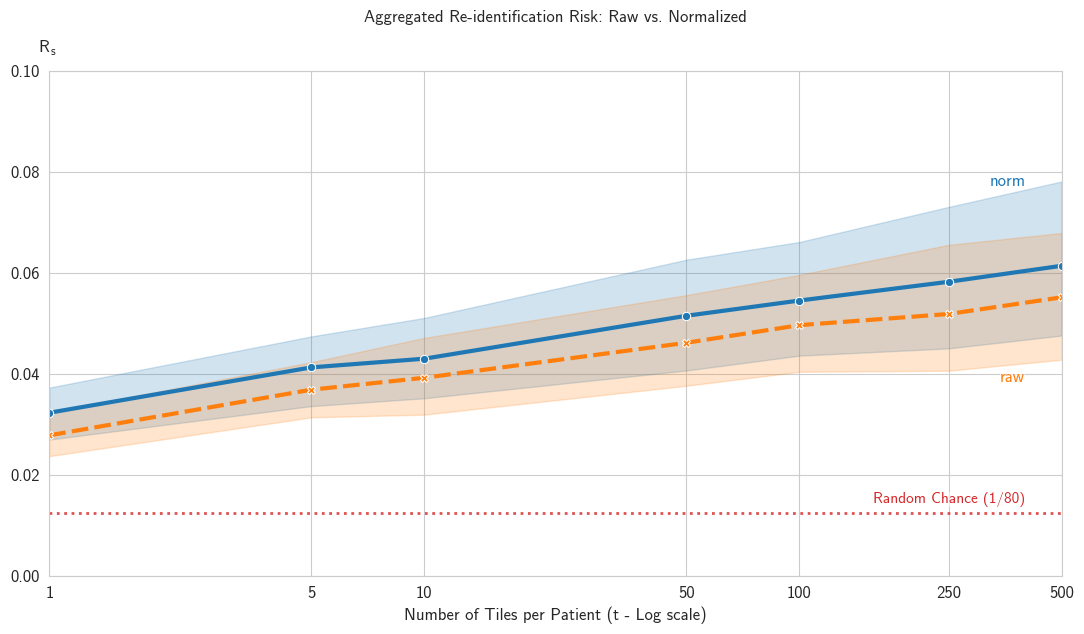

In [87]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.ticker import NullFormatter, ScalarFormatter

# --- 1. DATA LOADING AND PREPARATION ---
df_p = pd.read_csv("/home/jb88526/similarity/data/scaling_tiles_all.csv")

# Convert percentage to Success Rate (Rs)
df_p["Top1"] = df_p["Top1"] / 100
TILE_COUNTS = np.sort(df_p["N_Tiles"].unique())

N_GALLERY = 80
random_chance = 1 / N_GALLERY

# --- 2. IDENTICKÁ KONFIGURACE FONTŮ (STIXSANS) ---
sns.set_style("whitegrid")
plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": [
            "Computer Modern Sans Serif",
            "cmss10",
            "Helvetica",
            "Arial",
        ],
        "mathtext.fontset": "stixsans",
        "font.size": 12,
        "axes.titlesize": 12,
        "axes.labelsize": 12,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
        "legend.title_fontsize": 12,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "figure.facecolor": "white",
    }
)

# --- 3. VISUALIZATION ---
fig, ax = plt.subplots(figsize=(11, 6.5))

# Vykreslení křivek
sns.lineplot(
    data=df_p,
    x="N_Tiles",
    y="Top1",
    hue="Var",
    style="Var",
    markers=True,
    linewidth=3,
    errorbar=("ci", 95),
    legend=False, 
    ax=ax,
)

# ZMĚNA: Osa X je logaritmická, osa Y je LINEÁRNÍ
ax.set_xscale("log")
# ax.set_yscale('log') <-- TENTO ŘÁDEK JE ZAKOMENTOVANÝ / ODSTRANĚNÝ

# Formátování osy X (zůstává logaritmické rozložení)
ax.set_xticks(TILE_COUNTS)
ax.get_xaxis().set_major_formatter(ScalarFormatter())
ax.get_xaxis().set_minor_formatter(NullFormatter())

# Formátování osy Y (lineární krok od 0.0 do např. 0.1 nebo 0.15 podle vašich dat)
# Změňte max_y_limit podle toho, jak vysoko vaše křivky reálně sahají
max_y_limit = 0.10  
ax.set_yticks(np.arange(0.0, max_y_limit + 0.01, 0.02))

# Horizontální čára pro konstantní Random Chance (1/80)
ax.axhline(
    y=random_chance,
    color="#d62728",
    linestyle=":",
    linewidth=2,
    alpha=0.8,
)

# --- 4. FORMÁTOVÁNÍ POPISKŮ OS ---
ax.set_title(
    "Aggregated Re-identification Risk: Raw vs. Normalized",
    pad=35,
    fontweight="bold",
)
ax.set_xlabel("Number of Tiles per Patient (t - Log scale)")
ax.set_ylabel("") 

# R_s indexy bez mezer (odstranili jsme text "- Log scale" pro osu Y)
ax.text(
    x=0.0, y=1.03, s="R",
    transform=ax.transAxes, horizontalalignment="right", verticalalignment="bottom",
    fontsize=12, fontweight="bold",
)
ax.text(
    x=0.006, y=1.025, s="s",
    transform=ax.transAxes, horizontalalignment="right", verticalalignment="bottom",
    fontsize=9, fontweight="bold",
)

# --- 5. POPISKY JEDEN NAD ČÁROU, DRUHÝ POD ČÁROU ---
max_real_x = df_p["N_Tiles"].max()
lines = [l for l in ax.get_lines() if l.get_color() != "#d62728"]

# Přesné koncové hodnoty průměru
y_raw = df_p[(df_p["Var"] == "raw") & (df_p["N_Tiles"] == max_real_x)]["Top1"].mean()
y_norm = df_p[(df_p["Var"] == "norm") & (df_p["N_Tiles"] == max_real_x)]["Top1"].mean()

color_norm = lines[0].get_color()
color_raw = lines[1].get_color()

# POPISEK 1: "raw" (nad čáru)
ax.text(
    x=max_real_x - 100,        
    y=y_raw - 0.023,
    s="raw",
    horizontalalignment="right",
    fontsize=12,
    fontweight="bold",
    color=color_raw,
    bbox=dict(facecolor="white", alpha=0.5, edgecolor="none", pad=0)
)

# POPISEK 2: "norm" (pod čáru)
ax.text(
    x=max_real_x - 100,
    y=y_norm + 0.022,  # Posuneme ho trochu nahoru, aby nebyl přímo na čáře
    s="norm",
    horizontalalignment="right",
    fontsize=12,
    fontweight="bold",
    color=color_norm,
    bbox=dict(facecolor="white", alpha=0.5, edgecolor="none", pad=0)
)

# POPISEK 3: Random Chance
ax.text(
    x=max_real_x - 100,
    y=random_chance+0.002,
    s="Random Chance (1/80)",
    horizontalalignment="right",
    fontsize=11,
    color="#d62728",
    bbox=dict(facecolor="white", alpha=0.5, edgecolor="none", pad=0)
)

# Limity os: X s rezervou na popisky, Y lineárně od 0
ax.set_xlim(df_p["N_Tiles"].min(), max_real_x)
plt.ylim(0.0, max_y_limit)

plt.tight_layout()
plt.savefig("/home/jb88526/similarity/plots/synt_tiles.png", dpi=300, bbox_inches="tight")
plt.show()

# Different scanners

In [ ]:
enc = ["0", "1", "2", "3", "4"]
mpp = ["10"]

emb_col = [
    "vlad_default",
    "vlad_default_super",
    "fisher_default",
    "fisher_default_super",
    "mean_default",
    "mean_default_super"
]

types = ["prostate", "breast", "colon"]


In [ ]:
import urllib.parse
import re
import numpy as np
import pyarrow.parquet as pq
import faiss

def load_data_with_scanner_parsing(parquet_path, embedding_col="vlad_raw"):
    # Načtení tabulky
    table = pq.read_table(parquet_path, columns=[embedding_col, "__filename"])
    
    clean_embeddings = []
    clean_patient_ids = []
    clean_section_nums = []
    clean_scanners = []
    
    filenames = table.column("__filename").to_pylist()
    embeddings_list = table.column(embedding_col).to_pylist()

    for i in range(len(filenames)):
        # 1. Dekódování a vyčištění názvu
        decoded_path = urllib.parse.unquote(filenames[i])
        filename = decoded_path.split('/')[-1].upper()
        
        # 2. Filtry (markery)
        bad_markers = ["PSA", "CD34", "D240", "D2-40", "KI67", "ER", "PR", "HER2"]
        if any(m in filename for m in bad_markers):
            continue
            
        # 3. EXTRAKCE SCANNERU A PATIENT_ID
        # Regex vysvětlení:
        # ^([A-Z]+)       -> Najde počáteční písmena (MIDI, MIDITP, FLASH) - Skupina 1
        # .*?             -> Přeskočí případný nepořádek mezi tím
        # (\d{4}_.*?)     -> Najde rok a VŠE za ním až k příponě - Skupina 2
        # \.MRXS          -> Konec před příponou
        match = re.search(r'^([A-Z]+).*?(\d{4}_.*?)\.MRXS', filename)
        
        if match:
            raw_scanner = match.group(1)
            full_id_with_sections = match.group(2) # např. 2020_7590-01-0
            
            # --- OPRAVA ID ---
            # Odstraníme poslední pomlčku a cokoliv za ní (ten suffix -0 nebo -1)
            # rsplit('-', 1)[0] vezme vše před POSLEDNÍ pomlčkou
            clean_patient_id = full_id_with_sections.rsplit('-', 1)[0]
            
            # Sjednocení scanneru
            scanner = "FLASH" if "FLASH" in raw_scanner else "MIDI"
            
            # Extrakce čísla řezu (stále bereme to první číslo za pomlčkou)
            section_match = re.search(r'-(\d{1,2})', full_id_with_sections)
            if section_match:
                section_num = int(section_match.group(1))
                if section_num > 13: continue
            else:
                continue

            clean_embeddings.append(embeddings_list[i])
            # Teď ukládáme to očištěné ID (např. 2020_7590-01)
            clean_patient_ids.append(clean_patient_id) 
            clean_section_nums.append(section_num)
            clean_scanners.append(scanner)

    embeddings = np.array(clean_embeddings, dtype='float32')
    patient_ids = np.array(clean_patient_ids)
    section_nums = np.array(clean_section_nums)
    scanners = np.array(clean_scanners)
    
    if len(embeddings) > 0:
        faiss.normalize_L2(embeddings)
    
    print(f"File: {parquet_path.split('/')[-1]}")
    print(f"Sample Patient ID: {patient_ids[0] if len(patient_ids)>0 else 'N/A'}")
    print(f"Scanner: {np.unique(scanners)}")
    
    return patient_ids, section_nums, scanners, embeddings

In [ ]:
def calculate_rs_cross_scanner(patient_ids, scanners, embeddings):
    """
    Počítá Rs tak, že pro každý obrázek ze skeneru A hledá nejbližšího souseda 
    v datech ze skeneru B a naopak.
    """
    import faiss
    import numpy as np

    unique_scanners = np.unique(scanners)
    if len(unique_scanners) < 2:
        print("Chyba: V datech je pouze jeden typ skeneru. Cross-scanner Rs nelze spočítat.")
        return 0.0

    # Rozdělení dat podle skenerů
    mask_a = (scanners == unique_scanners[0])
    mask_b = (scanners == unique_scanners[1])

    ids_a, embs_a = patient_ids[mask_a], embeddings[mask_a]
    ids_b, embs_b = patient_ids[mask_b], embeddings[mask_b]

    # 1. SMĚR: Sonda je ze skeneru A, hledáme v B
    index_b = faiss.IndexFlatIP(embs_b.shape[1])
    index_b.add(embs_b)
    _, indices_in_b = index_b.search(embs_a, 1) # Hledáme 1 nejbližší (sami tam nejsme)
    
    # 2. SMĚR: Sonda je ze skeneru B, hledáme v A
    index_a = faiss.IndexFlatIP(embs_a.shape[1])
    index_a.add(embs_a)
    _, indices_in_a = index_a.search(embs_b, 1)

    # Vyhodnocení úspěšnosti (Sonda ID == Soused ID)
    correct_a_to_b = (ids_a == ids_b[indices_in_b.flatten()])
    correct_b_to_a = (ids_b == ids_a[indices_in_a.flatten()])

    # Sjednocení zranitelných pacientů (pacient je zranitelný, pokud byl 
    # identifikován alespoň v jednom směru)
    vulnerable_patients = set()
    
    # Pacienti identifikovaní ze skeneru A v B
    for i in range(len(ids_a)):
        if correct_a_to_b[i]:
            vulnerable_patients.add(ids_a[i])
            
    # Pacienti identifikovaní ze skeneru B v A
    for i in range(len(ids_b)):
        if correct_b_to_a[i]:
            vulnerable_patients.add(ids_b[i])

    all_patients = set(patient_ids)
    num_vulnerable = len(vulnerable_patients)
    total_patients = len(all_patients)
    rs = num_vulnerable / total_patients if total_patients > 0 else 0

    #print(f"--- Výsledek Cross-Scanner Rs ({unique_scanners[0]} <-> {unique_scanners[1]}) ---")
    #print(f"Celkem unikátních pacientů: {total_patients}")
    #print(f"Zranitelných pacientů napříč skenery: {num_vulnerable}")
    #print(f"Finální Cross-R_s: {rs:.4f}")

    return rs

In [ ]:
import gc
import pandas as pd
import os
import numpy as np

results_data = []    # Pro souhrnné Rs
detail_records = []  # Pro podrobný seznam cest a ID

# Definujeme rozsah seedů podle tvého pojmenování (42 až 61 včetně)
seeds = list(range(42, 62)) 

for e in enc:
    for t in types:
        # Základní cesta k experimentu
        base_path = f"/mnt/projects/ri_scale/privagams/{t}_enc{e}_slides_v5"
        
        if not os.path.exists(base_path):
            print(f"Base path not found: {base_path}")
            continue
            
        for seed in seeds:
            # Sestavení názvu složky podle tvého formátu: run_seed_X
            seed_folder = f"run_seed_{seed}"
            current_path = os.path.join(base_path, seed_folder)
            
            if not os.path.exists(current_path):
                # Volitelně: print(f"Skipping missing seed: {seed_folder}")
                continue
                
            for col in emb_col:
                #print(f"Processing: ENC={e}, TYPE={t}, {seed_folder}, COL={col}...")
                
                try:
                    # 1. Načtení dat pro konkrétní seed složku
                    pids, s_nums, scns, embs = load_data_with_scanner_parsing(current_path, col)
                    
                    # 2. Uložení DETAILŮ (např. jen pro první nalezený seed, ať nemáš miliony řádků)
                    if seed == seeds[0]:
                        for i in range(len(pids)):
                            detail_records.append({
                                "encoder": f"ENC_{e}",
                                "tissue_type": t,
                                "method": col,
                                "seed_folder": seed_folder,
                                "patient_id": pids[i],
                                "scanner": scns[i],
                                "section_num": s_nums[i]
                            })

                    # 3. Výpočet Rs (Cross-Scanner) pro daný seed
                    rs_val = calculate_rs_cross_scanner(pids, scns, embs)
                    
                    results_data.append({
                        "enc": f"Encoder {e}",
                        "method": col,
                        "rs_value": rs_val,
                        "type": t,
                        "seed": seed  # Tohle pak Seaborn použije pro výpočet intervalů
                    })

                    # Úklid paměti
                    del embs
                    gc.collect()    
                    
                except Exception as ex:
                    print(f"Chyba u {current_path}, {col}: {ex}")

# DataFrame pro grafy (obsahuje data pro všech 20 seedů na každou kombinaci)
df_results = pd.DataFrame(results_data)

# Kontrolní výpis průměrů
if not df_results.empty:
    df_summary = df_results.groupby(['enc', 'type', 'method'])['rs_value'].agg(['mean', 'std', 'count']).reset_index()
    print("\n--- SOUHRNNÉ VÝSLEDKY (Agregováno přes seedy) ---")
    print(df_summary)

    # Uložení pro pozdější vizualizaci
    df_results.to_csv("analyza_rs_seeds_42_61.csv", index=False)
else:
    print("Nebyla nalezena žádná data ke zpracování.")

Processing: ENC=0, TYPE=prostate, run_seed_42, COL=vlad_default...
File: run_seed_42
Sample Patient ID: 2020_6561-01
Scanner: ['FLASH' 'MIDI']
Processing: ENC=0, TYPE=prostate, run_seed_42, COL=vlad_default_super...
File: run_seed_42
Sample Patient ID: 2020_6561-01
Scanner: ['FLASH' 'MIDI']
Processing: ENC=0, TYPE=prostate, run_seed_42, COL=fisher_default...
File: run_seed_42
Sample Patient ID: 2020_6561-01
Scanner: ['FLASH' 'MIDI']
Processing: ENC=0, TYPE=prostate, run_seed_42, COL=fisher_default_super...
File: run_seed_42
Sample Patient ID: 2020_6561-01
Scanner: ['FLASH' 'MIDI']
Processing: ENC=0, TYPE=prostate, run_seed_42, COL=mean_default...
File: run_seed_42
Sample Patient ID: 2020_6561-01
Scanner: ['FLASH' 'MIDI']
Processing: ENC=0, TYPE=prostate, run_seed_42, COL=mean_default_super...
File: run_seed_42
Sample Patient ID: 2020_6561-01
Scanner: ['FLASH' 'MIDI']
Processing: ENC=0, TYPE=prostate, run_seed_43, COL=vlad_default...
File: run_seed_43
Sample Patient ID: 2020_6561-01
Sca

In [ ]:
df_results.to_csv("test.csv")

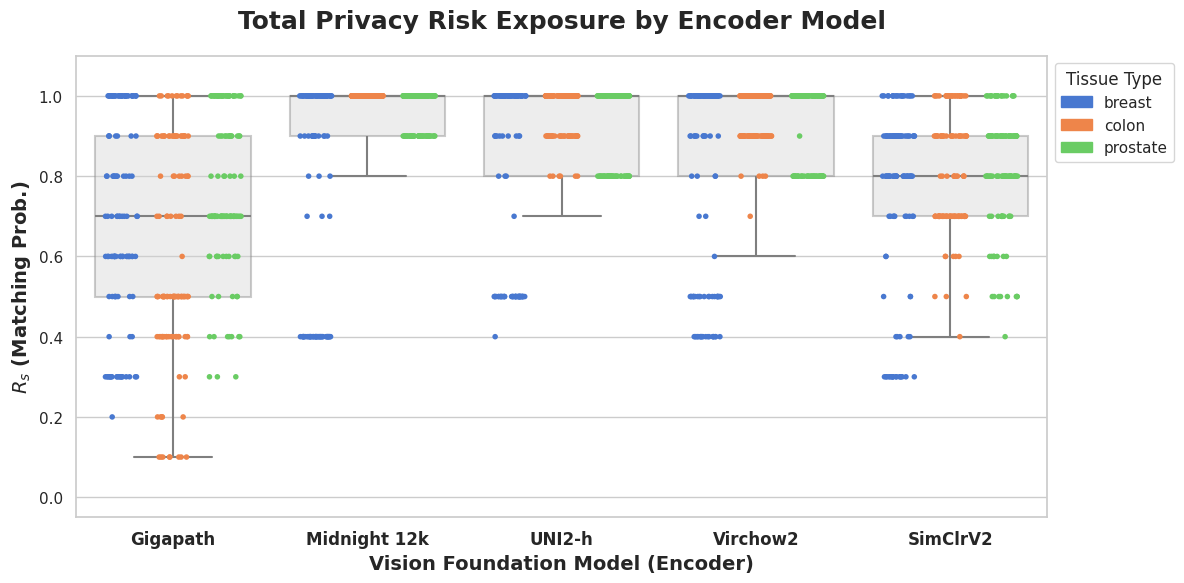

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import pandas as pd

if not df_results.empty:
    # --- 1. MAPOVÁNÍ NÁZVŮ (Zůstává stejné) ---
    nice_encoder_names = {
        "Encoder 0": "Gigapath",
        "Encoder 1": "Virchow2",
        "Encoder 2": "UNI2-h",
        "Encoder 3": "Midnight 12k",
        "Encoder 4": "SimClrV2"
    }
    df_results['encoder_name'] = df_results['enc'].map(nice_encoder_names).fillna(df_results['enc'])

    # --- 2. GRAF (Maximální agregace) ---
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, 6))
    
    # Hlavní boxplot - agreguje všechny metody, tkáně i seedy
    ax = sns.boxplot(
        data=df_results,
        x="encoder_name", 
        y="rs_value", 
        color="lightgray", 
        fliersize=0, 
        linewidth=1.5,
        boxprops={'alpha': 0.4}
    )

    # Stripplot - rozlišíme body podle tkání, abychom viděli variabilitu
    sns.stripplot(
        data=df_results,
        x="encoder_name", 
        y="rs_value", 
        hue="type", 
        palette="muted", 
        alpha=1.0, 
        dodge=True, 
        size=4,
        jitter=0.25,
        ax=ax
    )

    # --- 3. ÚPRAVA VZHLEDU ---
    plt.ylim(-0.05, 1.1)
    plt.ylabel("$R_s$ (Matching Prob.)", fontsize=14, fontweight='bold')
    plt.xlabel("Vision Foundation Model (Encoder)", fontsize=14, fontweight='bold')
    plt.xticks(fontsize=12, fontweight='bold')
    plt.yticks(fontsize=11)
    
    # Odstranění defaultní legendy stripplotu (vytvoříme vlastní)
    ax.get_legend().remove()

    # --- 4. VLASTNÍ LEGENDA A TITULEK ---
    tissues = sorted(df_results['type'].unique())
    palette = sns.color_palette("muted", len(tissues))
    patches = [mpatches.Patch(color=palette[i], label=t) for i, t in enumerate(tissues)]
    
    plt.legend(
        handles=patches,
        title="Tissue Type",
        loc='upper left',
        bbox_to_anchor=(1, 1),
        frameon=True,
        fontsize=11
    )

    plt.title("Total Privacy Risk Exposure by Encoder Model", 
              fontsize=18, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.show()

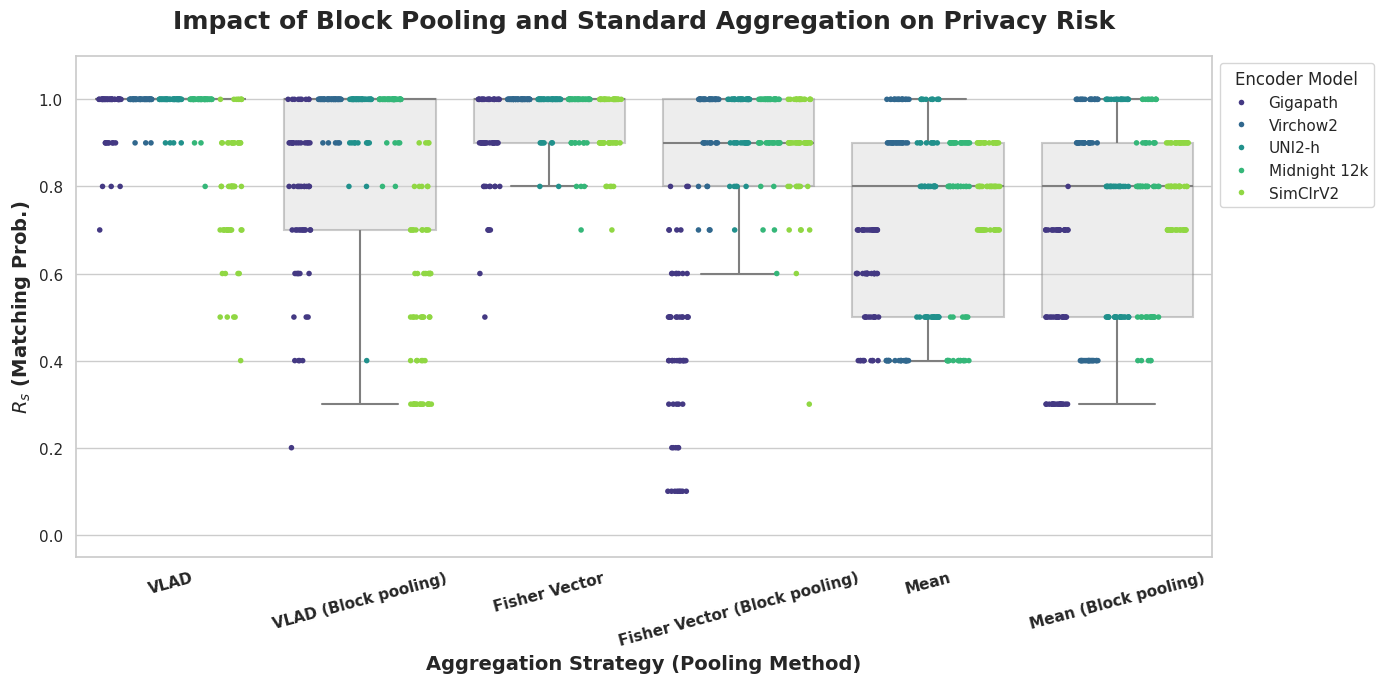

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import pandas as pd

if not df_results.empty:
    # --- 1. MAPOVÁNÍ NÁZVŮ METOD (Změna na Block pooling) ---
    nice_method_names = {
        "vlad_default": "VLAD",
        "vlad_default_super": "VLAD (Block pooling)",
        "fisher_default": "Fisher Vector",
        "fisher_default_super": "Fisher Vector (Block pooling)",
        "mean_default": "Mean",
        "mean_default_super": "Mean (Block pooling)",
    }
    df_results['method_nice'] = df_results['method'].map(nice_method_names).fillna(df_results['method'])
    
    # Definice pořadí pro osu X
    methods_order = ["VLAD", "VLAD (Block pooling)", "Fisher Vector", "Fisher Vector (Block pooling)", "Mean", "Mean (Block pooling)"]
    df_results['method_nice'] = pd.Categorical(df_results['method_nice'], categories=methods_order, ordered=True)
    df_results = df_results.sort_values('method_nice')

    # --- 2. GRAF (Agregace podle metod) ---
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(14, 7))
    
    # Hlavní boxplot
    ax = sns.boxplot(
        data=df_results,
        x="method_nice", 
        y="rs_value", 
        color="lightgray", 
        fliersize=0, 
        linewidth=1.5,
        boxprops={'alpha': 0.4}
    )

    # Stripplot s enkodéry
    sns.stripplot(
        data=df_results,
        x="method_nice", 
        y="rs_value", 
        hue="enc", 
        palette="viridis", 
        alpha=1.0, 
        dodge=True, 
        size=4,
        jitter=0.3,
        ax=ax
    )

    # --- 3. ÚPRAVA VZHLEDU ---
    plt.ylim(-0.05, 1.1)
    plt.ylabel("$R_s$ (Matching Prob.)", fontsize=14, fontweight='bold')
    plt.xlabel("Aggregation Strategy (Pooling Method)", fontsize=14, fontweight='bold')
    plt.xticks(rotation=15, fontsize=11, fontweight='bold')
    plt.yticks(fontsize=11)
    
    # Úprava legendy
    nice_encoder_names = ["Gigapath", "Virchow2", "UNI2-h", "Midnight 12k", "SimClrV2"]
    handles, _ = ax.get_legend_handles_labels()
    plt.legend(
        handles=handles,
        labels=nice_encoder_names,
        title="Encoder Model",
        loc='upper left',
        bbox_to_anchor=(1, 1),
        frameon=True
    )

    plt.title("Impact of Block Pooling and Standard Aggregation on Privacy Risk", 
              fontsize=18, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.show()

In [ ]:
enc = ["0", "1", "2", "3", "4"]
mpp = ["10"]

emb_col = [
    "vlad_default",
    "vlad_default_super",
    "fisher_default",
    "fisher_default_super",
    "mean_default",
    "mean_default_super"
]

types = ["prostate", "breast", "colon"]


In [ ]:
import os
import re
import urllib.parse
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import faiss
import gc
from pathlib import Path
from tqdm import tqdm

# ... tvé funkce load_data_with_scanner_parsing a calculate_rs_cross_scanner zůstávají stejné ...
# (Jen se ujisti, že v load_data_with_scanner_parsing bereš slide_id ze sloupce v parquetu, 
# pokud tam __filename už není)

def analyze_20_seeds(base_path, encoders, tissues, methods):
    results_data = []

    for e_idx, e_key in enumerate(encoders):
        for t in tissues:
            # Cesta k hlavní složce modelu a tkáně
            main_path = Path(base_path) / f"{t}_enc{e_key}_slides_v5"
            if not main_path.exists(): continue
            
            # Najdeme všech 20 runů
            seed_folders = sorted([d for d in main_path.iterdir() if "run_seed_" in d.name])
            
            for sf in tqdm(seed_folders, desc=f"Processing {e_key} {t}"):
                seed_val = sf.name.split("_")[-1]
                
                for col in methods:
                    try:
                        # Načteme všechny parquety v daném seedu
                        p_files = list(sf.glob("*.parquet"))
                        if not p_files: continue
                        
                        # Tady použijeme tvou logiku, ale upravenou pro DataFrame z parquetů
                        dfs = [pd.read_parquet(f) for f in p_files]
                        df_run = pd.concat(dfs)
                        
                        # --- PŘIZPŮSOBENÍ TVÉ LOGICE ---
                        # Pokud tvé parquety mají 'slide_id' místo '__filename', 
                        # musíme regex pustit na slide_id
                        
                        def parse_row(row):
                            filename = urllib.parse.unquote(row['slide_id']).split('/')[-1].upper()
                            match = re.search(r'^([A-Z]+).*?(\d{4}_.*?)\.MRXS', filename)
                            if match:
                                raw_scanner = match.group(1)
                                full_id = match.group(2)
                                clean_id = full_id.rsplit('-', 1)[0]
                                scanner = "FLASH" if "FLASH" in raw_scanner else "MIDI"
                                return pd.Series([clean_id, scanner])
                            return pd.Series([None, None])

                        # Aplikujeme tvůj regex na data v RAM
                        df_run[['pure_id', 'scanner']] = df_run.apply(parse_row, axis=1)
                        df_run = df_run.dropna(subset=['pure_id'])
                        
                        # Výpočet Rs (tvoje funkce calculate_rs_cross_scanner)
                        pids = df_run['pure_id'].values
                        scns = df_run['scanner'].values
                        embs = np.vstack(df_run[col].values).astype('float32')
                        faiss.normalize_L2(embs)
                        
                        rs_val = calculate_rs_cross_scanner(pids, scns, embs)
                        
                        results_data.append({
                            "enc": f"Encoder {e_idx}",
                            "method": col,
                            "rs_value": rs_val,
                            "type": t,
                            "seed": seed_val
                        })
                        
                        del embs, df_run; gc.collect()
                    except Exception as ex:
                        print(f"Chyba u {sf.name}, {col}: {ex}")

    return pd.DataFrame(results_data)

df_final = analyze_20_seeds("/mnt/projects/ri_scale/privagams/", enc, types, emb_col)

Processing 0 prostate:   0%|          | 0/20 [00:00<?, ?it/s]

Processing 4 colon: 100%|██████████| 20/20 [00:18<00:00,  1.10it/s]


In [ ]:
df_final.to_csv("test.csv")

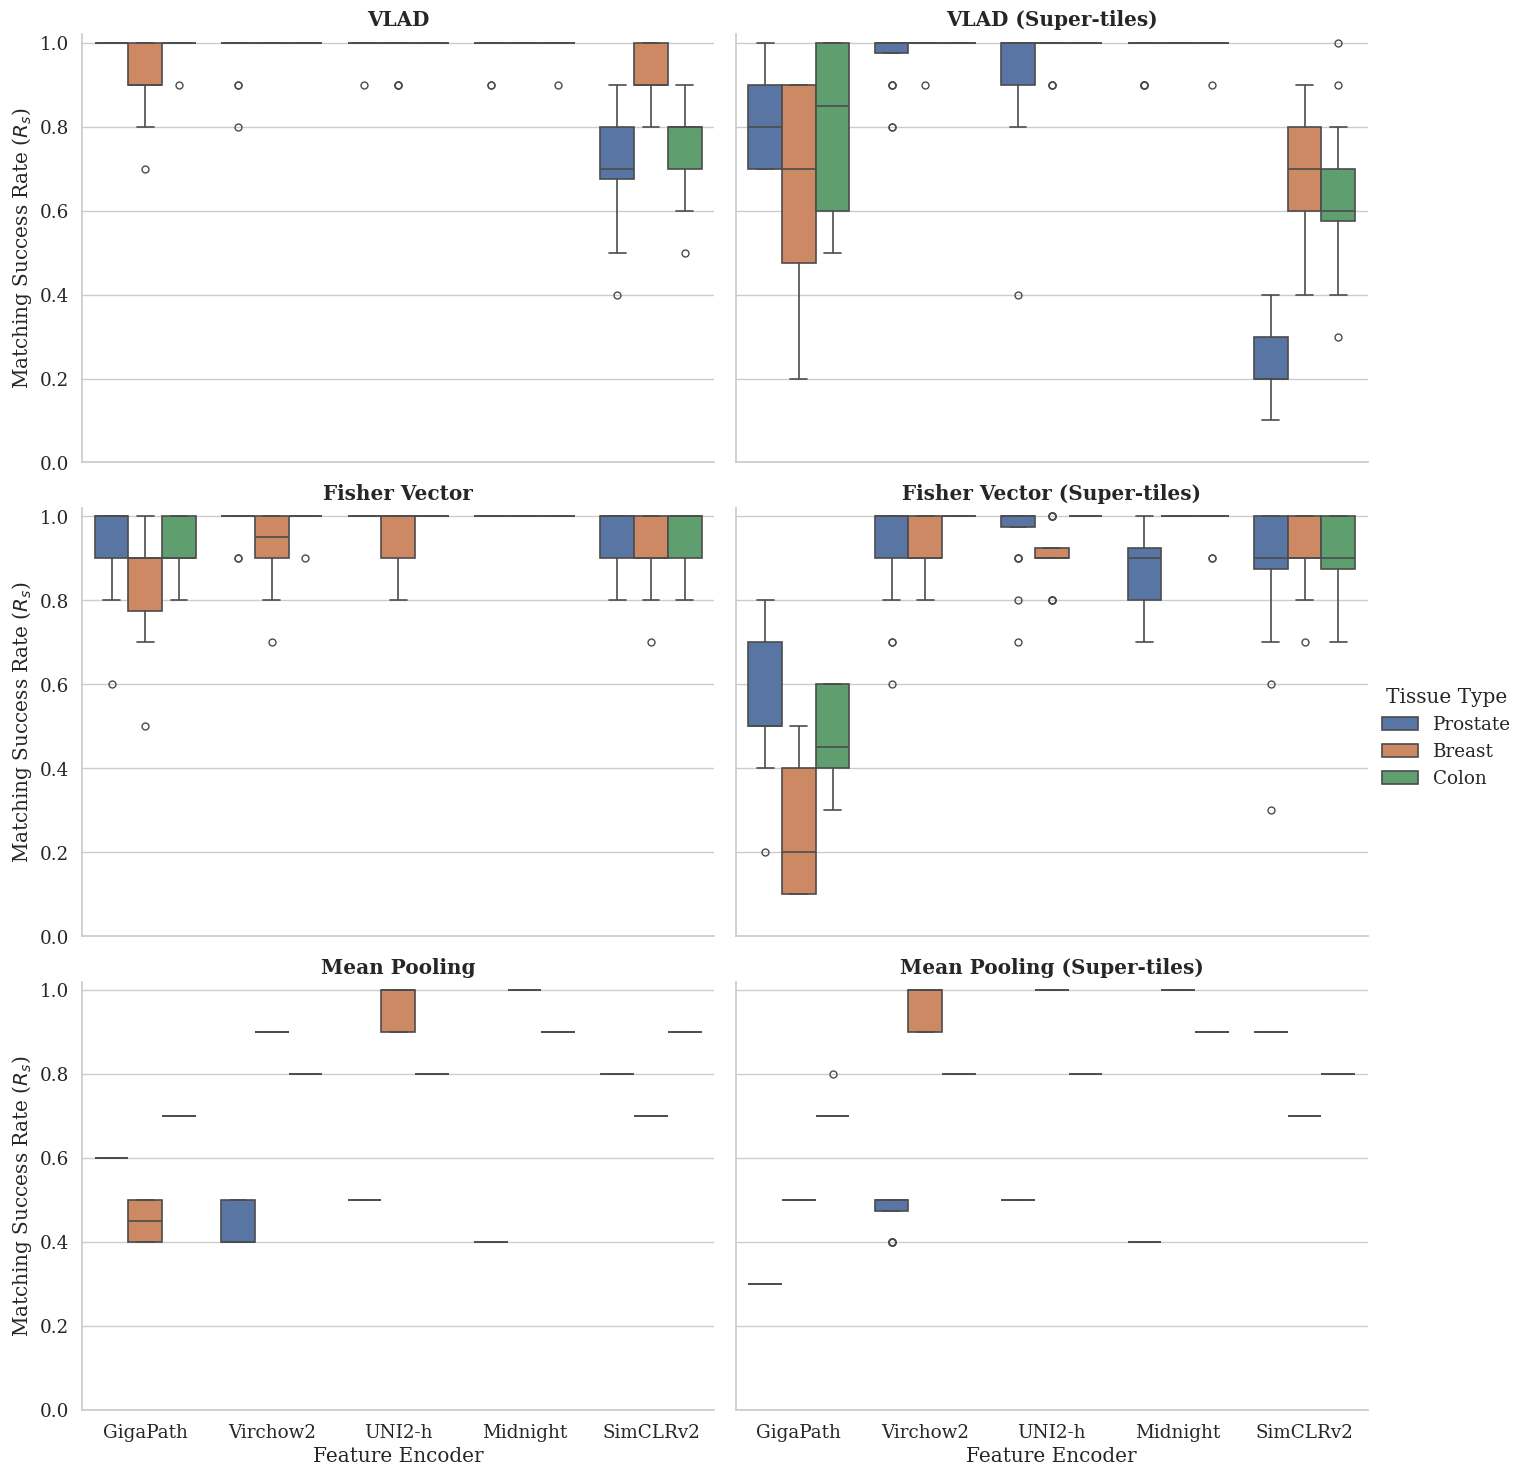

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Nastavení čistého stylu
sns.set_theme(style="whitegrid", font_scale=1.2) # Zvětšení základního písma
plt.rcParams['font.family'] = 'serif' # Serifové písmo vypadá v diplomkách lépe

nice_method_names = {
    "vlad_default": "VLAD",
    "vlad_default_super": "VLAD (Super-tiles)",
    "fisher_default": "Fisher Vector",
    "fisher_default_super": "Fisher Vector (Super-tiles)",
    "mean_default": "Mean Pooling",
    "mean_default_super": "Mean Pooling (Super-tiles)"
}

nice_encoder_names = {
    "Encoder 0": "GigaPath",
    "Encoder 1": "Virchow2",
    "Encoder 2": "UNI2-h",
    "Encoder 3": "Midnight",
    "Encoder 4": "SimCLRv2"
}

df_final['method_nice'] = df_final['method'].map(nice_method_names)
df_final['encoder_nice'] = df_final['enc'].map(nice_encoder_names)

# Vykreslení - odstranili jsme stripplot (tečky) pro čistší vzhled
g = sns.catplot(
    data=df_final,
    x="encoder_nice",
    y="rs_value",
    hue="type",
    col="method_nice",
    kind="box",      
    col_wrap=2,
    height=5,
    aspect=1.4,
    palette="deep",  # Paleta s lepšími kontrasty
    showfliers=True, # Outliery (prázdná kolečka) necháme, jsou důležité
    linewidth=1.2    # Trošku silnější linky boxů
)

# Úprava popisků a os
g.set_axis_labels("Feature Encoder", "Matching Success Rate ($R_s$)")
g.set_titles("{col_name}", weight='bold') # Tučné názvy podgrafů
g.set(ylim=(0, 1.02)) # Horní limit lehce nad 1 pro čistý okraj

# Odstranění suptitle (titulku v grafu) - v diplomce patří do caption pod obrázek
# Pokud ho tam přesto chceš, odkomentuj řádek níže:
# g.fig.suptitle("Evaluation of Privacy Risk across 20 Random Seeds", y=1.02)

# Úprava legendy
g._legend.set_title("Tissue Type")
for t in g._legend.texts:
    t.set_text(t.get_text().capitalize())

# Zlepšení rozvržení
#plt.tight_layout()

# DOPORUČENÍ: Ukládejte do PDF pro vektorovou kvalitu v diplomce
# plt.savefig("vysledky_robustnost.pdf", bbox_inches='tight')

plt.show()

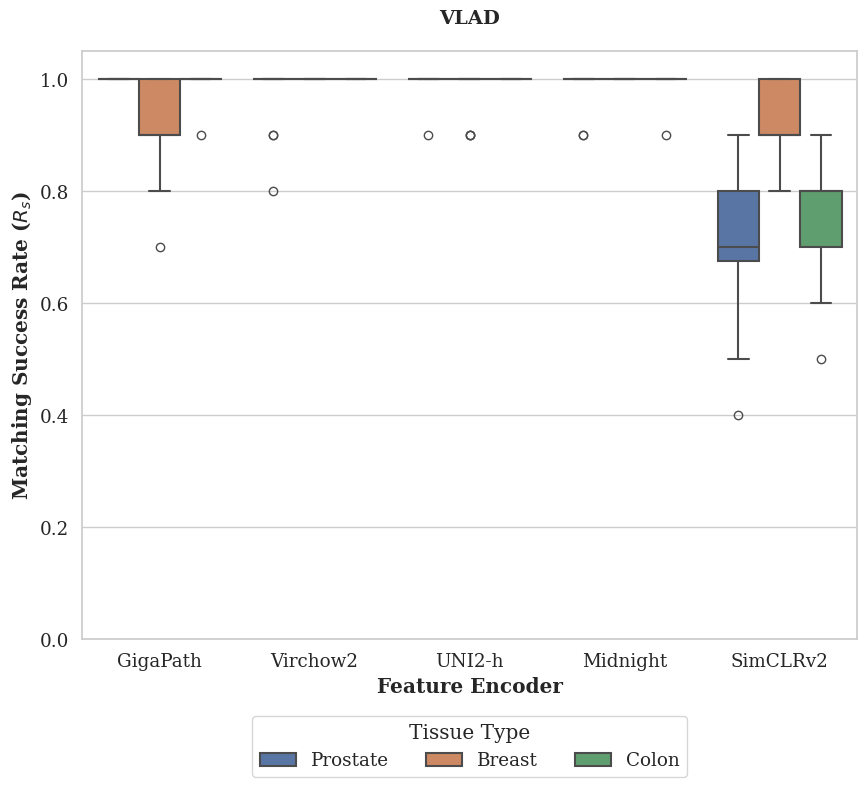

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Nastavení stylu pro diplomku
sns.set_theme(style="whitegrid", font_scale=1.2)
plt.rcParams['font.family'] = 'serif'

# 2. Mapování názvů (pouze pro čistý VLAD)
nice_encoder_names = {
    "Encoder 0": "GigaPath",
    "Encoder 1": "Virchow2",
    "Encoder 2": "UNI2-h",
    "Encoder 3": "Midnight",
    "Encoder 4": "SimCLRv2"
}

# 3. Filtrace dat - pouze standardní VLAD
df_vlad_single = df_final[df_final['method'] == 'vlad_default'].copy()
df_vlad_single['encoder_nice'] = df_vlad_single['enc'].map(nice_encoder_names)

# 4. Vykreslení
plt.figure(figsize=(10, 6))

ax = sns.boxplot(
    data=df_vlad_single,
    x="encoder_nice",
    y="rs_value",
    hue="type",
    palette="deep",
    showfliers=True,
    linewidth=1.5
)

# 5. Úprava os a titulků
plt.xlabel("Feature Encoder", fontweight='bold')
plt.ylabel("Matching Success Rate ($R_s$)", fontweight='bold')
plt.title("VLAD", fontsize=14, fontweight='bold', pad=20)
plt.ylim(0, 1.05)

# 6. FIX LEGENDY - Teď už bude 100% fungovat
# Capitalize popisků v legendě
handles, labels = ax.get_legend_handles_labels()
nice_labels = [l.capitalize() for l in labels]

plt.legend(
    handles=handles,
    labels=nice_labels,
    title="Tissue Type",
    loc='lower center',
    bbox_to_anchor=(0.5, -0.25), # Umístění pod osou X
    ncol=3,
    frameon=True
)

# 7. Úprava okrajů, aby se tam ta legenda vešla
plt.subplots_adjust(bottom=-0.1)

# Uložení (v PDF pro diplomku nejlepší)
# plt.savefig("vlad_standard_results.pdf", bbox_inches='tight')

plt.show()